# Libraries and functions

## libraries

In [1]:
## Standard libraries
import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import scipy as sp
from matplotlib.colors import ListedColormap, Normalize, BoundaryNorm
plt.rcParams.update({'font.size': 14})
import random
import math
from tqdm import tqdm
import time
import copy
import gc

## PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data
import torch.optim as optim
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
import torchvision.transforms as transforms


data_PATH = "./data/"
DATASET_PATH = "/content/data"
CHECKPOINT_PATH = "/content/saved_models"

device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
print("Device:", device)

Device: cpu


## Functions

In [2]:
#Checkpoints (to save model parameters during training)
class SaveBestModel:
    def __init__(self, name, print=True, best_valid_loss=-float('inf')): #object initialized with best_loss = +infinite
        self.best_valid_loss = best_valid_loss
        self.print = print
        self.name = name

    def __call__(
        self, current_valid_loss,
        epoch, model, optimizer, criterion, criterion_f, time, asymmetry=None, overlap=None
    ):
        if current_valid_loss >= self.best_valid_loss:
            self.best_valid_loss = current_valid_loss
            if self.print==True:
                print("Saving best model for epoch: %d, current val loss: %.4e, t: %.1f\n" % (epoch+1, current_valid_loss, time))
            # method to save a model (the state_dict: a python dictionary object that
            # maps each layer to its parameter tensor) and other useful parametrers
            # see: https://pytorch.org/tutorials/beginner/saving_loading_models.html
            if asymmetry is not None and overlap is not None:
                torch.save({
                    'epoch': epoch+1,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'loss': criterion,
                    "time": time,
                    "asymmetry": asymmetry,
                    "overlap": overlap,
                    }, self.name)
            else:
                torch.save({
                    'epoch': epoch+1,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'loss': criterion,
                    "loss_f": criterion_f,
                    "time": time,
                }, self.name)

#Checkpoints (to save model parameters during training)
class Save_Model:
    def __init__(self, name, print=True): #object initialized with best_loss = +infinite
        self.print = print
        self.name = name

    def __call__(
        self, current_valid_loss,
        epoch, model, optimizer, criterion, criterion_f=None, time=None, asymmetry=None, overlap=None
    ):

        if asymmetry is not None and overlap is not None:
            torch.save({
                'epoch': epoch+1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'loss': criterion,
                "time": time,
                "asymmetry": asymmetry,
                "overlap": overlap,
                }, self.name)
        else:
            torch.save({
                'epoch': epoch+1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'loss': criterion,
                "loss_f": criterion_f,
                "time": time,
            }, self.name)

def loss_single_i(output):                        #out.shape = [B]
    g_i_b = output
    loss = g_i_b.mean()
    return loss

def running_mean(x, N):
    cumsum = np.cumsum(np.insert(x, 0, 0))
    return (cumsum[N:] - cumsum[:-N]) / float(N)

In [3]:
from scipy.special import iv as scipy_iv

class BesselIvFunction(torch.autograd.Function):
    @staticmethod
    def forward(ctx, nu, x):
        # Use scipy to compute the forward pass
        result = torch.from_numpy(scipy_iv(nu.item(), x.cpu().numpy())).to(x.device)
        # Save the input for the backward pass
        ctx.save_for_backward(x, torch.tensor(nu))
        return result

    @staticmethod
    def backward(ctx, grad_output):
        x, nu = ctx.saved_tensors
        # Use the recurrence relation for the derivative of the modified Bessel function of the first kind
        # d/dx [I_nu(x)] = I_(nu-1)(x) - (nu/x) * I_nu(x)
        iv_nu = BesselIvFunction.apply(nu, x)
        iv_nu_minus_1 = BesselIvFunction.apply(nu - 1, x)
        grad_x = grad_output * (iv_nu_minus_1 - (nu / x) * iv_nu)
        return None, grad_x

In [4]:
def evaluate_loss(model, dataset, device,l):
    train_loss = 0.0
    counter = 0
    model.eval()
    with torch.no_grad():
        for batch_element in dataloader: #takes a batch from the train dataloader
            for i in range(N):
                counter += 1
                inp_data = batch_element
                inp_data = inp_data.to(device)

                B = inp_data.shape[0]

                loss = model(inp_data, i_rand= i, lambd=l)
                train_loss += loss.item()

        train_loss = train_loss/(counter)

    return train_loss

In [5]:
def compute_asymmetry(J: np.ndarray) -> float:
    # Ensure that J is a NumPy array
    J = np.array(J)

    # Step 1: Compute the difference between J and its transpose
    asymmetry_matrix = J - J.T

    # Step 2: Square each element in the asymmetry matrix
    squared_diff_matrix = np.square(asymmetry_matrix)

    # Step 3: Compute the mean of the squared differences
    asymmetry = np.mean(squared_diff_matrix)

    return asymmetry

In [6]:
def start_overlap_binary(xi: torch.Tensor, init_overlap: float) -> torch.Tensor:
    # Copy xi to avoid modifying the input directly
    init_vectors = xi.clone()

    # Get the dimensions of the input tensor
    X, N, d = init_vectors.shape

    # For each position of X
    for x in range(X):
        # Calculate the number of rows to flip (multiply by -1)
        num_rows_to_flip = int(N * ((1-init_overlap) / 2.))

        # Randomly choose 'num_rows_to_flip' unique indices from the N rows
        indices_to_flip = torch.randperm(N)[:num_rows_to_flip]

        # Multiply the selected rows by -1
        init_vectors[x, indices_to_flip, :] *= -1

    return init_vectors

In [7]:
def basins_of_attraction_xi(init_overlaps_array, model, dataset, num_of_run, n, device):
    max_overlap_xi_list = []

    # Loop over each init_overlap value
    for init_overlap in init_overlaps_array:
        # Generate input_vectors based on the init_overlap
        input_vectors = start_overlap_binary(dataset.xi, init_overlap)

        # Normalize input_vectors using the model's normalization method
        input_vectors = model.normalize_x(input_vectors)

        # Send the input_vectors to the appropriate device (e.g., GPU/CPU)
        input_vectors = input_vectors.to(device)

        # Run the converge function to get the necessary outputs
        overlap_max_n_xi, overlap_max_n_f, max_overlap_xi, max_overlap_f, final_overlap, _, overlap_argmax = converge(input_vectors[:num_of_run], model, dataset, n)

        # Append the computed max_overlap_xi to the list
        max_overlap_xi_list.append(overlap_max_n_xi[:num_of_run,-1])

    # Convert the list to a NumPy array
    max_overlap_xi_array = np.array(max_overlap_xi_list)

    return max_overlap_xi_array

In [8]:
def basins_of_attraction_f(init_overlaps_array, model, dataset, num_of_run, n, device):
    max_overlap_f_list = []

    # Loop over each init_overlap value
    for init_overlap in init_overlaps_array:
        # Generate input_vectors based on the init_overlap
        input_vectors = start_overlap_binary(dataset.f, init_overlap)

        # Normalize input_vectors using the model's normalization method
        input_vectors = model.normalize_x(input_vectors)

        # Send the input_vectors to the appropriate device (e.g., GPU/CPU)
        input_vectors = input_vectors.to(device)

        # Run the converge function to get the necessary outputs
        overlap_max_n_xi, overlap_max_n_f, max_overlap_xi, max_overlap_f, final_overlap, _, overlap_argmax = converge(input_vectors[:num_of_run], model, dataset, n, features=True)

        # Append the computed max_overlap_xi to the list
        max_overlap_f_list.append(overlap_max_n_f[:num_of_run,-1])

    # Convert the list to a NumPy array
    max_overlap_f_array = np.array(max_overlap_f_list)

    return max_overlap_f_array

### Dynamics analisys functions

In [9]:
import torch

def max_overlap(x_new, vectors):
    """
    Computes the maximum overlap and corresponding indices between x_new and vectors.

    Args:
    - x_new: Tensor of shape [batch_size, n, N, d].
    - vectors: Tensor of shape [X, N, d].

    Returns:
    - overlap_max: Tensor of maximum overlap values of shape [batch_size].
    - max_values: Tensor of corresponding max values of shape [batch_size].
    """
    batch_size, n, N, d = x_new.shape
    X = vectors.shape[0]

    # Step 1: Compute dot products for each [N, d] pair in x_new and vectors.
    # Resulting shape: [batch_size, n, X, N]
    dot_products = torch.einsum('bnid,xid->bnxi', x_new, vectors)

    # Step 2: Compute the mean over the N dimension.
    # Resulting shape: [batch_size, n, X]
    dot_products_mean = dot_products.mean(dim=3)    #[b,n,x]

    # Step 3: Compute max and argmax over the n dimension.
    # Resulting shapes: [batch_size, n], [batch_size, n]
    overlap_max_n, overlap_argmax_n = torch.max(dot_products_mean, dim=-1)

    # Step 4: Compute max and argmax over the X dimension.
    # Resulting shapes: [batch_size], [batch_size]
    overlap_max, overlap_argmax = torch.max(overlap_max_n, dim=1)
    max_values = overlap_max_n.gather(1, overlap_argmax.unsqueeze(-1)).squeeze()

    return overlap_max_n.cpu().numpy(), overlap_max.cpu().numpy(), max_values.cpu().numpy(), overlap_argmax.cpu().numpy()


In [10]:
def converge(input_vectors, model, dataset, n, features=False):
    """
    Function to perform dynamics and compute overlaps.

    Args:
    - input_vectors: Tensor of shape [batch_size, N, d].
    - model: The model instance with a dyn_n_step method.
    - dataset: The dataset instance containing xi and f.
    - n: The number of steps to simulate.

    Returns:
    - max_overlap_xi: Tensor of max overlap values with xi.
    - max_overlap_f: Tensor of max overlap values with f.
    - final_overlap: Tensor of final overlap values with input_vectors.
    """
    # Step 1: Compute x_new using the model's dyn_n_step method
    x_new = model.dyn_n_step(input_vectors, n)  #[B,n,N,d]

    # Step 2: Calculate max overlaps using dataset.xi and dataset.f
    overlap_max_n_xi, max_overlap_xi, _,overlap_argmax = max_overlap(x_new, dataset.xi.to(device))
    if features == True:
        overlap_max_n_f, max_overlap_f, _, _ = max_overlap(x_new, dataset.f.to(device))
    else:
        overlap_max_n_f = np.zeros_like(overlap_max_n_xi)
        max_overlap_f = np.zeros_like(max_overlap_xi)

    input_overlap_n = torch.einsum('bnid,bid->bni', x_new, input_vectors).mean(dim=-1)  #[b,n]
    max_input_overlap = torch.max(input_overlap_n, dim=1)[0].cpu().numpy()

    return overlap_max_n_xi, overlap_max_n_f, max_overlap_xi, max_overlap_f, input_overlap_n.cpu().numpy(), max_input_overlap, overlap_argmax

In [11]:
def converge_input_vector_compute_overlap(input_data, model, init_overlap, n):
    input_vectors = start_overlap_binary(input_data, init_overlap)

    input_vectors = model.normalize_x(input_vectors)
    input_vectors = input_vectors.to(device)
    x_new = model.dyn_n_step(input_vectors, n)  #[B, n, N,i]
    overlap = torch.einsum('bnid,bid->bni', x_new, input_data).mean(dim=-1)  #[b,n]
    return overlap

def basins_of_attraction_inp_vectors(input_data, init_overlaps_array, model, n):
    max_overlap_inp_vectors_list = []

    # Loop over each init_overlap value
    for init_overlap in init_overlaps_array:
        # Generate input_vectors based on the init_overlap
        overlaps = converge_input_vector_compute_overlap(input_data, model, init_overlap, n)[:,-1]
        max_overlap_inp_vectors_list.append(overlaps.detach().cpu())

    # Convert the list to a NumPy array
    max_overlap_inp_vectors_array = np.array(max_overlap_inp_vectors_list)
    return max_overlap_inp_vectors_array

## High-level functions

In [12]:
def initialize_MNIST(N=1000, d=1, on_sphere=True, l=1, device='cuda', selected_images=None, test_images=None):
    # Initialize the dataset
    dataset = CustomDataset(P, N, D, d, seed=555, sigma=0.5, on_sphere=on_sphere, coefficients="binary")
    dataset.xi = torch.tensor(selected_images).unsqueeze(2).type(torch.float)

    dataset_test = CustomDataset(P_test, N, D, d, seed=555, sigma=0.5, on_sphere=on_sphere, coefficients="binary")
    dataset_test.xi = torch.tensor(test_images).unsqueeze(2).type(torch.float)

    # Initialize the model
    model = TwoBodiesModel(N, d, on_sphere).to(device)
    #model.to(device)  # Move the model to the specified device

    # Apply the Hebb rule
    #model.Hebb(dataset.xi, 'Tensorial')

    # Return the dataset and model
    return dataset, dataset_test, model


In [13]:
def train_model(model, dataloader, epochs, learning_rate, lr_factor, device, data_PATH, model_name, init_overlap, n, valid_every=10, alpha=None):
    # Initial setup
    norm_0 = torch.tensor(1)
    norm = torch.tensor(1)

    # Initialize SaveBestModel class
    #save_best_model = SaveBestModel(data_PATH + "models/" + model_name, print=False)

    # Initialize histories
    hist_loss = []
    hist_vloss = []
    hist_asymm = []
    hist_diff = []
    hist_J_norm = []

    t_in = time.time()

    model.to(device)
    model2 = copy.deepcopy(model)
    model2.to(device)
    J2 = model2.J.squeeze().cpu().detach().numpy()
    norm_J2 = np.linalg.norm(J2)

    # Training loop
    for epoch in range(epochs):
        t0 = time.time()
        model.train()
        train_loss = 0.0
        counter = 0

        # Training batch-wise
        for batch_element in dataloader:
            counter += 1
            inp_data = batch_element.to(device)

            # Compute loss
            loss = model(inp_data, lambd=l)

            # Check for valid loss values (no NaN or Inf)
            if (torch.isnan(loss).any() == False) and (torch.isinf(loss).any() == False):
                model.zero_grad()
                with torch.no_grad():
                    # Backward and gradient descent
                    loss.backward()
                    for param in model.parameters():
                        param.data -= learning_rate * param.grad
                    train_loss += loss.item()
            else:
                print("Detected nan")

        # Average training loss
        train_loss = train_loss / counter
        hist_loss.append(train_loss)

        learning_rate = learning_rate * lr_factor
        #if epoch == int(epochs/4.):
        #    learning_rate = learning_rate/5

        #if epoch == int(epochs/2.):
        #    learning_rate = learning_rate/5

        # Validation and model saving
        if epoch % valid_every == 0 and epoch > 0:
            model.eval()
            vali_loss = 0.0
            counter = 0

            with torch.no_grad():
                for batch_element in dataloader:
                    counter += 1
                    inp_data = batch_element.to(device)

                    # Overlap and model dynamics computations
                    input_vectors = start_overlap_binary(inp_data, init_overlap)
                    input_vectors = model.normalize_x(input_vectors)
                    x_new = model.dyn_n_step(input_vectors, n)

                    # Overlap calculations
                    overlaps = torch.einsum('bnid,bid->bni', x_new, inp_data).mean(dim=-1)  # [b,n]
                    final_overlaps = overlaps[:, -1]
                    max_input_overlap, _ = torch.max(overlaps, dim=-1)

                    vloss = final_overlaps.mean().cpu().numpy()
                    vali_loss += vloss

            if counter != 0:
                vali_loss = vali_loss / counter
            hist_vloss.append(vali_loss)

            # Save best model
            elapsed_time = time.time() - t0
            time_from_in = time.time() - t_in
            #save_best_model(vali_loss, epoch, model, fake_opt, hist_vloss, time_from_in)

            # Compute model parameters for logging
            J = model.J.squeeze().cpu().detach().numpy()
            norm_J = np.linalg.norm(J)
            asymmetry = compute_asymmetry(J)
            diff_Hebb = np.linalg.norm(J2 * norm_J / norm_J2 - J) / norm_J

            # Append to history
            hist_asymm.append(asymmetry)
            hist_diff.append(diff_Hebb)
            hist_J_norm.append(norm_J)

            # Print final statistics if it's the last epoch
            if epoch == epochs - 1:
                print(f"epoch: {epoch+1}, train loss: {train_loss:.6f}, final_ov: {vali_loss:.5f}, max_ov: {max_input_overlap.mean().cpu().numpy():.5f}, "
                      f"lr: {learning_rate:.2e}, J_norm: {norm_J:.2e}, asym: {asymmetry:.3e}, diff: {diff_Hebb:.3e}")

    # Return training history for further analysis
    return model, hist_loss, hist_vloss, hist_asymm, hist_diff, hist_J_norm


In [14]:
def train_model_graph_lambda(model, dataloader, epochs, epochs_to_save, learning_rate, lr_factor,device, data_PATH, model_name, model_name_base, init_overlap, n, valid_every=10, alpha=None):
    # Initial setup
    norm_0 = torch.tensor(1)
    norm = torch.tensor(1)

    # Initialize SaveBestModel class
    #save_best_model = SaveBestModel(data_PATH + "models/" + model_name, print=False)

    # Initialize histories
    hist_loss = []
    hist_vloss = []
    hist_asymm = []
    hist_diff = []
    hist_J_norm = []

    t_in = time.time()

    model.to(device)
    model2 = copy.deepcopy(model)
    model2.to(device)
    J2 = model2.J.squeeze().cpu().detach().numpy()
    norm_J2 = np.linalg.norm(J2)

    # Training loop
    for epoch in tqdm(range(epochs)):
        t0 = time.time()
        model.train()
        train_loss = 0.0
        counter = 0

        # Training batch-wise
        for batch_element in dataloader:
            counter += 1
            inp_data = batch_element.to(device)

            # Compute loss
            loss = model(inp_data, lambd=l)

            # Check for valid loss values (no NaN or Inf)
            if (torch.isnan(loss).any() == False) and (torch.isinf(loss).any() == False):
                model.zero_grad()
                with torch.no_grad():
                    # Backward and gradient descent
                    loss.backward()
                    for param in model.parameters():
                        param.data -= learning_rate * param.grad
                    train_loss += loss.item()
            else:
                print("Detected nan")

        # Average training loss
        train_loss = train_loss / counter
        hist_loss.append(train_loss)

        # Validation and model saving
        if epoch % valid_every == 0 and epoch > 0:
            model.eval()
            vali_loss = 0.0
            counter = 0

            with torch.no_grad():
                for batch_element in dataloader:
                    counter += 1
                    inp_data = batch_element.to(device)

                    # Overlap and model dynamics computations
                    input_vectors = start_overlap_binary(inp_data, init_overlap)
                    input_vectors = model.normalize_x(input_vectors)
                    x_new = model.dyn_n_step(input_vectors, n)

                    # Overlap calculations
                    overlaps = torch.einsum('bnid,bid->bni', x_new, inp_data).mean(dim=-1)  # [b,n]
                    final_overlaps = overlaps[:, -1]
                    max_input_overlap, _ = torch.max(overlaps, dim=-1)

                    vloss = final_overlaps.mean().cpu().numpy()
                    vali_loss += vloss

            if counter != 0:
                vali_loss = vali_loss / counter
            hist_vloss.append(vali_loss)

            # Save best model
            elapsed_time = time.time() - t0
            time_from_in = time.time() - t_in
            #save_best_model(vali_loss, epoch, model, fake_opt, hist_vloss, time_from_in)

            # Compute model parameters for logging
            J = model.J.squeeze().cpu().detach().numpy()
            norm_J = np.linalg.norm(J)
            asymmetry = compute_asymmetry(J)
            diff_Hebb = np.linalg.norm(J2 * norm_J / norm_J2 - J) / norm_J

            # Append to history
            hist_asymm.append(asymmetry)
            hist_diff.append(diff_Hebb)
            hist_J_norm.append(norm_J)

            # Print final statistics if it's the last epoch
            if epoch == epochs - 1:
                print(f"epoch: {epoch+1}, train loss: {train_loss:.6f}, final_ov: {vali_loss:.5f}, max_ov: {max_input_overlap.mean().cpu().numpy():.5f}, "
                      f"lr: {learning_rate:.2e}, J_norm: {norm_J:.2e}, asym: {asymmetry:.3e}, diff: {diff_Hebb:.3e}")

        if epoch in epochs_to_save:
            model_name_save = model_name_base + "_epoch_{}.pth".format(epoch)
            save_model = Save_Model(data_PATH + "models/" + model_name_save, print=False)
            save_model(vali_loss, epoch, model, fake_opt, hist_vloss, time=time_from_in)

    # Return training history for further analysis
    return model, hist_loss, hist_vloss, hist_asymm, hist_diff, hist_J_norm


In [15]:
def compute_model_outputs(model, dataset, num_to_compute, init_overlap, n, device):

    # Extract and move input data to the specified device
    inp_data = dataset#.xi[:num_to_compute].to(device)

    # Overlap and model dynamics computations
    input_vectors = start_overlap_binary(inp_data, init_overlap)
    input_vectors = model.normalize_x(input_vectors)
    x_new = model.dyn_n_step(input_vectors, n)

    # Overlap calculations
    overlaps = torch.einsum('bnid,bid->bni', x_new, inp_data).mean(dim=-1)  # [b, n]
    final_overlaps = overlaps[:, -1]  # Final overlaps (last dimension)

    # Extract the last repetition of x_new and convert to numpy
    x_final = x_new[:, -1].detach().cpu().numpy()
    overlaps = overlaps.detach().cpu().numpy()

    return x_final, input_vectors, overlaps


In [16]:
import matplotlib.pyplot as plt

def plot_model_computations(
    model, dataset, dataset_test, indices, init_overlap, n, device, suptitle
):

    # Extract the three images from both datasets
    images_train = dataset.xi[indices].to(device)  # Training images
    images_test = dataset_test.xi[indices].to(device)  # Test images

    dimensions = images_train.shape
    #print(dimensions)

    to_save = np.zeros((3,dimensions[0], dimensions[1], dimensions[2]))
    to_save_test = np.zeros((3,dimensions[0], dimensions[1], dimensions[2]))

    # Compute x_finals and final_overlaps for training and test images
    x_final_train, modified_images_train, overlaps_train = compute_model_outputs(
        model, images_train, len(indices), init_overlap, n, device
    )
    x_final_test, modified_images_test, overlaps_test = compute_model_outputs(
        model, images_test, len(indices), init_overlap, n, device
    )

    to_save[0] = images_train.detach().cpu().numpy()
    to_save[1] = modified_images_train.detach().cpu().numpy()
    to_save[2] = x_final_train

    to_save_test[0] = images_test.detach().cpu().numpy()
    to_save_test[1] = modified_images_test.detach().cpu().numpy()
    to_save_test[2] = x_final_test

    # Calculate final overlaps for suptitle
    mean_final_overlap_train = overlaps_train[:, -1].mean()
    mean_final_overlap_test = overlaps_test[:, -1].mean()

    # Convert x_final to CPU for visualization
    x_final_train = torch.tensor(x_final_train).cpu()
    x_final_test = torch.tensor(x_final_test).cpu()
    modified_images_train = torch.tensor(modified_images_train).cpu()
    modified_images_test = torch.tensor(modified_images_test).cpu()

    full_suptitle = "init overlap:{:.3f} final train:{:.3f}, final test:{:.3f}".format(
        init_overlap,
        mean_final_overlap_train,
        mean_final_overlap_test
    )


    # Plotting
    fig, axes = plt.subplots(3, 6, figsize=(15, 10))

    for i in range(3):
        # Training dataset
        axes[i, 0].imshow(images_train[i].view(14,14).cpu().squeeze(), cmap="gray_r")
        axes[i, 0].set_title("Original (Train)")
        axes[i, 1].imshow(modified_images_train[i].view(14,14).squeeze(), cmap="gray_r")
        axes[i, 1].set_title("Modified (Train)")
        axes[i, 2].imshow(x_final_train[i].view(14,14).squeeze(), cmap="gray_r")
        axes[i, 2].set_title("x_final (Train)")

        # Test dataset
        axes[i, 3].imshow(images_test[i].view(14,14).cpu().squeeze(), cmap="gray_r")
        axes[i, 3].set_title("Original (Test)")
        axes[i, 4].imshow(modified_images_test[i].view(14,14).squeeze(), cmap="gray_r")
        axes[i, 4].set_title("Modified (Test)")
        axes[i, 5].imshow(x_final_test[i].view(14,14).squeeze(), cmap="gray_r")
        axes[i, 5].set_title("x_final (Test)")

    # Adjust layout
    for ax in axes.flat:
        ax.axis("off")

    plt.suptitle(suptitle+" "+full_suptitle, fontsize=18)

    plt.tight_layout()
    plt.show()

    return to_save, to_save_test


# Models

In [17]:
import torch
import torch.nn as nn

class TwoBodiesModel(nn.Module):
    def __init__(self, N, d, on_sphere, r=1):
        super(TwoBodiesModel, self).__init__()
        self.N = N
        self.d = d
        self.on_sphere = on_sphere
        self.r = r

        self.J = nn.Parameter(torch.randn(N, N, d, d))
        self.normalize_J()

        self.mask = torch.ones(N, N, device=self.J.device)  # Shape [N, N]
        self.mask.fill_diagonal_(0)  # Set diagonal to 0

        # Expand the mask to match the shape of J (to broadcast correctly)
        self.mask = self.mask.unsqueeze(-1).unsqueeze(-1)  # Shape [N, N, 1, 1]

    def normalize_J(self):
        with torch.no_grad():
            self.J.data *= torch.sqrt(torch.tensor(1/(self.N*self.d)))

    def symmetrize_J(self):
        with torch.no_grad():
            self.J.data = (self.J.data + self.J.data.transpose(0,1))/2

    def normalize_x(self, x):
        """
        Normalize each d-dimensional vector in x on the sphere if self.on_sphere is True.
        """
        if self.on_sphere:
            with torch.no_grad():
                norms = x.norm(dim=-1, keepdim=True)+1e-9
                x = x / norms
        return x

    def Hebb(self, xi, form):
        """
        Calculates J based on the Hebb rule.
        xi -- input tensor of shape [P, N, d]
        form -- a string, either "Isotropic" or "Tensorial"
        """
        P = xi.shape[0]  # Number of patterns
        N = self.N
        d = self.d

        if form not in ["Isotropic", "Tensorial"]:
            raise ValueError("Form must be either 'Isotropic' or 'Tensorial'")

        # Zero out self.J to calculate the new values based on xi
        with torch.no_grad():
            self.J.zero_()

            # Hebbian rule for Isotropic or Tensorial form
            if form == "Isotropic":
                for mu in range(P):
                    # For Isotropic form: J_ij = (1/N) * sum(xi_i^mu * xi_j^mu)
                    for i in range(N):
                        for j in range(N):
                            if i != j:
                                self.J[i, j, :, :] += torch.sum(xi[mu, i, :] * xi[mu, j, :]) / P
            elif form == "Tensorial":
                for mu in tqdm(range(P)):
                    xi_mu = xi[mu]  # Shape: (N, D)
                    outer_products = torch.einsum('ia,jb->ijab', xi_mu, xi_mu) / P  # Shape: (N, N, D)

                    # Zero out diagonal elements
                    indices = torch.arange(N)
                    outer_products[indices, indices] = 0

                    # Update self.J
                    self.J += outer_products

    def dyn_step(self, x, a=None):
        """
        Computes x_{t+1} = sum_j J_ij * x_j and then normalizes it.
        x -- input tensor of shape [N, d]
        """
        B, N, d = x.shape
        diagonal = self.J.data.diagonal(dim1=0, dim2=1)  # Get diagonal elements
        diagonal.fill_(0)
        with torch.no_grad():
            if a is None:
                x_new = torch.einsum('ijab,Bjb->Bia', self.J, x)
            else:
                x_new = x + a*torch.einsum('ijab,Bjb->Bia', self.J, x)
            x_new = self.normalize_x(x_new)
        return x_new

    def dyn_n_step(self, x, n, a=None, bar=False):
        """
        Computes the dynamics for n steps.
        Args:
        x -- input tensor of shape [B, N, d]
        n -- number of steps
        Returns:
        Tensor of shape [B, n, N, d] containing the dynamics over n steps
        """
        B, N, d = x.shape
        # Initialize the tensor to store the states over n steps
        x_new = torch.zeros(n, B, N, d, device=x.device)
        x_new_temp = x.clone()

        # Iterate and evolve the system for n steps
        if bar==True:
            for t in tqdm(range(n)):
                x_new_temp = self.dyn_step(x_new_temp, a)
                x_new[t] = x_new_temp
        else:
            for t in range(n):
                x_new_temp = self.dyn_step(x_new_temp, a)
                x_new[t] = x_new_temp

        return x_new.permute(1, 0, 2, 3)

    def Z_i_mu_func(self, y_i_mu, lambd, r=1):
        Z_i_mu = 2*torch.cosh(lambd*r*y_i_mu)  # [M, N]
        return Z_i_mu


    def forward(self, xi_batch, lambd, i_rand=None, r=1):
        if i_rand is not None:
            J_x = torch.einsum('jab,mjb->ma', self.J[i_rand], xi_batch)  # [M, d]
            y_i_mu = J_x.norm(dim=-1)  # Taking the norm over the last dimension -> [M]
            x_J_x = torch.einsum('ma,ma->m', xi_batch[:,i_rand], J_x)  # [M, N]

            # Compute the energy term for each mu
            energy_i_mu = -x_J_x + (1 / lambd) * torch.log(self.Z_i_mu_func(y_i_mu,lambd,r)+1e-9)  # [M]

        else:
            J_x = torch.einsum('ijab,mjb->mia',  self.J * self.mask.to(device), xi_batch)  # [M, d]
            y_i_mu = J_x.norm(dim=-1)  # Taking the norm over the last dimension -> [M,N]
            x_J_x = torch.einsum('mia,mia->mi', xi_batch, J_x)  # [M, N]

            # Compute the energy term for each mu
            energy_i_mu = -x_J_x + (1 / lambd) * torch.log(self.Z_i_mu_func(y_i_mu,lambd,r)+1e-9)  # [M,N]
            energy_i_mu = energy_i_mu.mean(dim=1)

        return energy_i_mu.mean(dim=0)

    def compute_stabilities(self, xi_input, total=False):
        xi = xi_input.clone()

        eta = torch.einsum("pid,pjd->pij",xi,xi) # Shape: [P, N, N]

        # 1. Compute J_i (the row vector for each i): Shape [N, N]
        J_norm = torch.norm(self.J.squeeze(), dim=1)  # Norm of each row in J, Shape: [N]

        # 2. Compute the dot product 
        dot_products = torch.einsum('ij,pij->pi', self.J.squeeze(), eta)  # Shape: [P, N]

        # 3. Normalize by the magnitude of J_i
        delta = dot_products / J_norm.unsqueeze(0)  # Shape: [P, N]

        delta_min = delta.min().item()
        delta_max = delta.max().item()
        delta_mean = delta.mean().item()

        if total==False:

            return np.array([delta_min, delta_mean, delta_max])
        else:
            return delta


In [18]:
'''
# Example usage:
model = TwoBodiesModel(N=200, d=3, on_sphere=True)
xi = torch.randn(5, 200, 3)  # Example input tensor of shape [P, N, d]
norms = xi.norm(dim=2, keepdim=True)
xi = xi / norms
model.Hebb(xi, 'Tensorial')  # Applying the Hebb rule
result = model.forward(xi)  # Using the forward pass
print(result[:2,:2])
'''

"\n# Example usage:\nmodel = TwoBodiesModel(N=200, d=3, on_sphere=True)\nxi = torch.randn(5, 200, 3)  # Example input tensor of shape [P, N, d]\nnorms = xi.norm(dim=2, keepdim=True)\nxi = xi / norms\nmodel.Hebb(xi, 'Tensorial')  # Applying the Hebb rule\nresult = model.forward(xi)  # Using the forward pass\nprint(result[:2,:2])\n"

In [19]:
'''
x = xi[0]
x_init = x+torch.randn(200,3)/1
norms = x.norm(dim=1, keepdim=True)
x_init = x_init / norms
print(x_init.shape)
x_new = model.dyn_step(x_init)
print(x_new.shape)
#
#print(norms)
'''

'\nx = xi[0]\nx_init = x+torch.randn(200,3)/1\nnorms = x.norm(dim=1, keepdim=True)\nx_init = x_init / norms\nprint(x_init.shape)\nx_new = model.dyn_step(x_init)\nprint(x_new.shape)\n#\n#print(norms)\n'

In [20]:
'''
x_new = x_init.clone()
print(((x-x_new)**2).mean())
for t in range(10):
    x_new = model.dyn_step(x_new)
    print(((x-x_new)**2).mean())
'''

'\nx_new = x_init.clone()\nprint(((x-x_new)**2).mean())\nfor t in range(10):\n    x_new = model.dyn_step(x_new)\n    print(((x-x_new)**2).mean())\n'

# Create crop MNIST dataset as in Belyaev and Velichko 2020

In [21]:
from pathlib import Path
import numpy as np
from scipy import ndimage


def load_mnist():
    from torchvision.datasets import MNIST
    train_ds = MNIST(root="./mnist_data", train=True, download=True)
    test_ds = MNIST(root="./mnist_data", train=False, download=True)
    x_train = train_ds.data.numpy().astype(np.uint8)
    y_train = train_ds.targets.numpy().astype(np.int64)
    x_test = test_ds.data.numpy().astype(np.uint8)
    y_test = test_ds.targets.numpy().astype(np.int64)
    return x_train, y_train, x_test, y_test


def deskew_mnist(img: np.ndarray) -> np.ndarray:
    img_f = img.astype(np.float32)

    total = img_f.sum()
    if total <= 1e-8:
        return img.copy()

    h, w = img.shape
    ys, xs = np.indices((h, w), dtype=np.float32)

    cx = (img_f * xs).sum() / total
    cy = (img_f * ys).sum() / total

    x = xs - cx
    y = ys - cy

    mu11 = (img_f * x * y).sum() / total
    mu02 = (img_f * y * y).sum() / total

    if abs(mu02) < 1e-8:
        return img.copy()

    skew = mu11 / mu02

    center_y = (h - 1) / 2.0
    matrix = np.array([[1.0, 0.0],
                       [skew, 1.0]], dtype=np.float32)
    offset = np.array([0.0, -skew * center_y], dtype=np.float32)

    deskewed = ndimage.affine_transform(
        img_f,
        matrix=matrix,
        offset=offset,
        output_shape=(h, w),
        order=1,
        mode="constant",
        cval=0.0,
    )

    return np.clip(np.rint(deskewed), 0, 255).astype(np.uint8)


def center_crop(img: np.ndarray, crop_size: int = 14) -> np.ndarray:
    """
    Center-crop a square image to crop_size x crop_size.
    For 28x28 -> 14x14 this removes 7 pixels from each border.
    """
    h, w = img.shape
    if crop_size > h or crop_size > w:
        raise ValueError("crop_size must be <= image dimensions")

    top = (h - crop_size) // 2
    left = (w - crop_size) // 2
    return img[top:top + crop_size, left:left + crop_size]


def preprocess_dataset(images: np.ndarray, crop_size: int = 14) -> np.ndarray:
    """
    Apply deskew + center crop + row-wise flattening to all images.

    Returns:
        flat_images: shape (N, crop_size*crop_size), dtype=int
    """
    n = images.shape[0]
    out = np.empty((n, crop_size * crop_size), dtype=np.int16)

    for i in range(n):
        d = deskew_mnist(images[i])
        c = center_crop(d, crop_size=crop_size)
        out[i] = c.reshape(-1)

    return out


def save_txt_dataset(
    out_dir: str = "./modified_mnist_txt",
    crop_size: int = 14,
    save_class_means: bool = True,
):
    out_path = Path(out_dir)
    out_path.mkdir(parents=True, exist_ok=True)

    x_train, y_train, x_test, y_test = load_mnist()

    train_flat = preprocess_dataset(x_train, crop_size=crop_size)

    test_flat = preprocess_dataset(x_test, crop_size=crop_size)

    train_img_name = f"mnist_train_imgs_crop{crop_size}.txt"
    test_img_name = f"mnist_test_imgs_crop{crop_size}.txt"

    np.savetxt(out_path / train_img_name, train_flat, fmt="%d", delimiter=",")
    np.savetxt(out_path / "mnist_train_labels.txt", y_train, fmt="%d")
    np.savetxt(out_path / test_img_name, test_flat, fmt="%d", delimiter=",")
    np.savetxt(out_path / "mnist_test_labels.txt", y_test, fmt="%d")

    print(f"Saved: {out_path / train_img_name}")
    print(f"Saved: {out_path / 'mnist_train_labels.txt'}")
    print(f"Saved: {out_path / test_img_name}")
    print(f"Saved: {out_path / 'mnist_test_labels.txt'}")

    return train_flat, y_train, test_flat, y_test




In [22]:
save_txt_dataset(
    out_dir="./data/modified_mnist_txt",
    crop_size=14,
    save_class_means=True,
)

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9912422/9912422 [00:01<00:00, 9536046.04it/s] 


Extracting ./mnist_data/MNIST/raw/train-images-idx3-ubyte.gz to ./mnist_data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28881/28881 [00:00<00:00, 259715.99it/s]


Extracting ./mnist_data/MNIST/raw/train-labels-idx1-ubyte.gz to ./mnist_data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1648877/1648877 [00:00<00:00, 2408300.97it/s]


Extracting ./mnist_data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./mnist_data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4542/4542 [00:00<00:00, 1551093.37it/s]


Extracting ./mnist_data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./mnist_data/MNIST/raw

Saved: data/modified_mnist_txt/mnist_train_imgs_crop14.txt
Saved: data/modified_mnist_txt/mnist_train_labels.txt
Saved: data/modified_mnist_txt/mnist_test_imgs_crop14.txt
Saved: data/modified_mnist_txt/mnist_test_labels.txt


(array([[246, 253, 253, ..., 228, 141,  40],
        [  0,   3,  23, ..., 231, 181,  85],
        [ 64,   0,   0, ...,  57,   0,   0],
        ...,
        [  0,   0,   0, ..., 153, 198,  51],
        [  0,   0,   0, ...,  88,  14,   1],
        [  0,  23,  75, ...,   0,   0,   0]], dtype=int16),
 array([5, 0, 4, ..., 5, 6, 8]),
 array([[173, 155, 108, ...,   0,   0,   0],
        [  0,  66, 227, ..., 253, 253, 253],
        [  0,   0,   0, ...,   0,   0,   0],
        ...,
        [  0,   1,  36, ...,   0,   0,   0],
        [  0,   0,   0, ..., 252, 234, 142],
        [  0,  13,  55, ..., 253, 243, 160]], dtype=int16),
 array([7, 2, 1, ..., 4, 5, 6]))

(60000, 196)


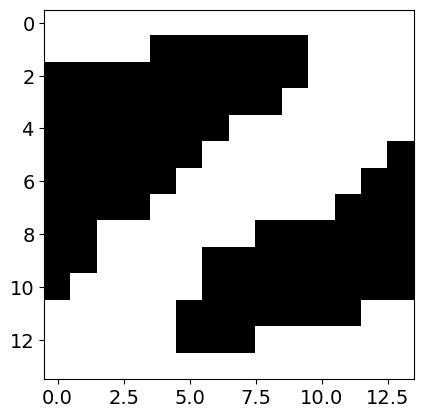

(60000, 196)


In [27]:
data_PATH = "./data/modified_mnist_txt/"

name = "mnist_train_imgs_crop14.txt"
images = np.loadtxt(data_PATH + name, delimiter=",", dtype=int)
labels_name = "mnist_train_labels.txt"
labels = np.loadtxt(data_PATH + labels_name, delimiter=",", dtype=int)
print(images.shape)

plt.imshow((images[25] > 86).reshape(14, 14), cmap="gray")
plt.show()

images_binarized = (images > 86).astype(np.float64) * 2 - 1
print(images_binarized.shape)

## Compute overlap between data

In [28]:
import torch

data = torch.tensor(images_binarized)
B, N = data.shape
chunk = 4096 

s = torch.zeros(N, device=device, dtype=torch.float32)
for i in range(0, B, chunk):
    x = data[i:i+chunk].to(device=device, dtype=torch.float32, non_blocking=True)
    s += x.sum(dim=0)

sum_offdiag_dot = (s @ s) - B * N
mean_overlap = sum_offdiag_dot / (N * B * (B - 1))
print("Mean overlap, ", mean_overlap.item())

Mean overlap,  0.08878493309020996


In [29]:
import torch

# images_binarized: shape (B, N), entries in {-1, +1}
# labels: shape (B,)

data = torch.as_tensor(images_binarized, dtype=torch.float32)
y = torch.as_tensor(labels)

B, N = data.shape
classes = torch.unique(y, sorted=True)

class_sums = []
class_counts = []

for c in classes:
    x_c = data[y == c]
    class_sums.append(x_c.sum(dim=0))
    class_counts.append(x_c.shape[0])

class_sums = torch.stack(class_sums)                  # shape (C, N)
class_counts = torch.tensor(class_counts).float()     # shape (C,)

dot_matrix = class_sums @ class_sums.T               # (C, C)

denom = N * class_counts[:, None] * class_counts[None, :]
overlap_matrix = dot_matrix / denom

mask = ~torch.eye(len(classes), dtype=torch.bool)
mean_interclass_overlap = overlap_matrix[mask].mean()

print("Mean inter-class overlap:", mean_interclass_overlap.item())

Mean inter-class overlap: 0.05943800508975983


# Dataset

## RF

In [22]:
class CustomDataset(Dataset):
    def __init__(self, P, N, D, d, sigma, seed=None, on_sphere=True, coefficients="gaussian"):
        """
        P: Number of patterns
        N: Number of sites
        D: Number of features in the random field
        d: Dimensionality of each site
        sigma: Standard deviation of the Gaussian noise
        on_sphere: If True, normalize data to lie on a sphere
        coefficients: Type of coefficients ('binary' or 'gaussian')
        """
        self.P = P
        self.N = N
        self.D = D
        self.d = d
        self.sigma = sigma
        self.on_sphere = on_sphere
        self.coefficients = coefficients

        if seed is not None:
            torch.manual_seed(seed)

        # xi of shape [P, N, d]
        self.xi = torch.randn(P, N, d) * sigma

        # If D > 0, modify xi using the RF method
        if self.D > 0:
            self.RF()

        # Normalize xi along last dimension if on_sphere is True

    def RF(self):
        # Create tensor f of shape [D, N, d] with random Gaussian numbers (std = sigma)
        self.f = torch.randn(self.D, self.N, self.d) * self.sigma

        # Normalize f along the last dimension if on_sphere is True
        if self.on_sphere:
            self.f = self.normalize(self.f)

        # Create tensor c of shape [P, D] based on coefficient type
        if self.coefficients == "binary":
            self.c = torch.randint(0, 2, (self.P, self.D)).float() * 2 - 1  # Random +1 or -1
        elif self.coefficients == "gaussian":
            self.c = torch.randn(self.P, self.D)  # Gaussian random numbers
        else:
            raise ValueError("coefficients must be 'binary' or 'gaussian'")

        # Divide c by sqrt(D)
        self.c = self.c / math.sqrt(self.D)

        # Update xi: xi[p] = sum_{k=0}^D c[p,k] * f[k]
        self.xi = torch.einsum('pk,kia->pia', self.c, self.f)
        # Create a mask where self.xi == 0
        mask = self.xi == 0

        # Generate random binary values (-1 or +1) for the positions where mask is True
        random_binary_values = torch.randint(0, 2, self.xi.shape, device=self.xi.device) * 2 - 1

        # Assign the random binary values to positions where self.xi == 0
        self.xi = torch.where(mask, random_binary_values, self.xi)

        if self.on_sphere:
            self.xi = self.normalize(self.xi)

    def get_generalization(self, P_hat, L=None):  #P_hat number of generalization vectors to get, L number of features to use
        if L==None:
            L = self.D
        if L>self.D:
            raise ValueError("L must be less than or equal to D")

        # Create tensor c of shape [P, N] based on coefficient type
        if self.coefficients == "binary":
            self.c = torch.randint(0, 2, (P_hat, self.D)).float() * 2 - 1  # Random +1 or -1
        elif self.coefficients == "gaussian":
            self.c = torch.randn(P_hat, self.D)  # Gaussian random numbers
        else:
            raise ValueError("coefficients must be 'binary' or 'gaussian'")

        # Divide c by sqrt(D)
        self.c = self.c / math.sqrt(self.D)

        #For each row of self.c, set to zero self.D-L random entries among the self.D. For each row, different random entries to set to zero
        indices_to_zero = torch.rand(self.P, self.D)
        indices_to_zero = indices_to_zero.argsort(dim=1)[:,:self.D-L]
        self.c = self.c.scatter(1, indices_to_zero, 0)

        # xi_new: xi[p] = sum_{k=0}^D c[p,k] * f[k]
        self.xi_new = torch.einsum('pk,kia->pia', self.c, self.f)
        self.xi_new = self.normalize(self.xi_new)
        return self.xi_new


    def normalize(self, x):
        # Normalize each d-dimensional vector in x along the last dimension
        norms = x.norm(dim=-1, keepdim=True)
        return x / norms

    def __len__(self):
        # Return the number of patterns P
        return self.P

    def __getitem__(self, index):
        # Return the pattern xi at the given index
        return self.xi[index]

In [23]:
class DatasetF(Dataset):
    def __init__(self, D, f):
        self.D = D
        self.f = f

    def __len__(self):
        return self.D

    def __getitem__(self, index):
        return self.f[index]

In [24]:
# Example usage:
#dataset = CustomDataset(P=200, N=200, D=5, d=3, sigma=0.5, on_sphere=True, coefficients="binary")

## MNIST

In [49]:
import numpy as np

name = "mnist_train_imgs_crop14.txt"
# Specify the delimiter as a comma
images = np.loadtxt(data_PATH+name, delimiter=',', dtype=int)
images.shape

(60000, 196)

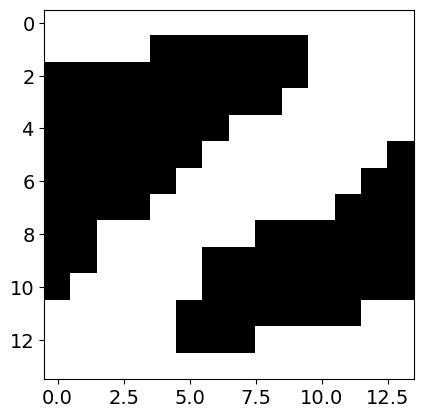

In [50]:
plt.imshow((images[25]>86).reshape(14,14), cmap='gray')

In [51]:
images_binarized = (images>86).astype(np.float64)*2-1
images_binarized.shape

(60000, 196)

# Training

## Study single training in function of norm

In [ ]:
N=196
#a_P_values = np.flip(np.logspace(np.log10(0.1), np.log10(100), num=10))
a_P_values = np.flip(np.logspace(np.log10(10), np.log10(100), num=1))

epochs_to_save = np.logspace(np.log10(10), np.log10(1000), num=10).astype("int")

P_test = 10000
D=0
d=1
on_sphere=True

l=1.
valid_every=10
epochs=1001
learning_rate=1.
lr_factor = 1.003
init_overlap=1.
n=10
max_norm=100


In [ ]:
to_save_overlaps = np.zeros((len(a_P_values),2))

for i_a, a_P in enumerate(a_P_values):
    P = int(a_P*N)
    print("P= ",P)
    batch_size = min(P,1000)
    batch_size_test = batch_size
    np.random.seed(555)

    # Shuffle the images along the first axis (axis=0)
    shuffled_indices = np.random.permutation(images_binarized.shape[0])
    shuffled_images = images_binarized[shuffled_indices]

    # Select the first P images
    selected_images = shuffled_images[:P]
    num_to_test = P_test
    test_images = shuffled_images[P:(P+num_to_test)]

    gc.collect()
    torch.cuda.empty_cache()

    dataset, dataset_test, model = initialize_MNIST(N=N, d=1, on_sphere=True, l=l, device='cuda', selected_images=selected_images, test_images=test_images)
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True, num_workers=2)
    dataloader_test = torch.utils.data.DataLoader(dataset_test, batch_size=batch_size_test, shuffle=False, drop_last=True, num_workers=2)

    fake_opt = torch.optim.SGD(model.parameters(), lr=learning_rate)

    model_name = "MNIST_GD_N{}_P{}_init_random_no_batch_no_adamw_binary.pth".format(N,P)
    model_name_base = "MNIST_GD_N{}_P{}_init_random_no_batch_no_adamw_binary".format(N,P)

    #############################################################
    model.Hebb(dataset.xi.to(device), "Tensorial")
    model.J.data = 0.01*model.J.data
    #############################################################

    model, hist_loss, hist_vloss, hist_asymm, hist_diff, hist_J_norm = train_model_graph_lambda(model, dataloader, epochs, epochs_to_save, learning_rate, lr_factor, device, data_PATH, model_name, model_name_base, init_overlap, n, valid_every=10, alpha=None)

    to_save_overlaps[i_a,0] = hist_vloss[-1]

    counter_test = 0
    vali_loss_test = 0
    for batch_element in dataloader_test:
        counter_test +=1
        inp_data = batch_element
        inp_data = inp_data.to(device)
        input_vectors = start_overlap_binary(inp_data, init_overlap)
        input_vectors = model.normalize_x(input_vectors)
        x_new = model.dyn_n_step(input_vectors, n)
        overlaps = torch.einsum('bnid,bid->bni', x_new, inp_data).mean(dim=-1)         #[b,n
        final_overlaps = overlaps[:,-1]
        max_input_overlap,_ = torch.max(overlaps, dim=-1)
        vloss_test = final_overlaps.mean().cpu().numpy()
        vali_loss_test += vloss_test

    if counter_test !=0:
        vali_loss_test = vali_loss_test/(counter_test)

    to_save_overlaps[i_a,1] = vali_loss_test
    print("Overlap test: ", vali_loss_test)


P=  1960


100%|██████████| 1001/1001 [02:17<00:00,  7.30it/s]

epoch: 1001, train loss: 0.143511, final_ov: 0.78261, max_ov: 0.89902, lr: 1.00e+00, J_norm: 1.35e+01, asym: 1.556e-04, diff: 8.739e-01


Overlap test:  0.7638888


### Starting random 0.01 norm

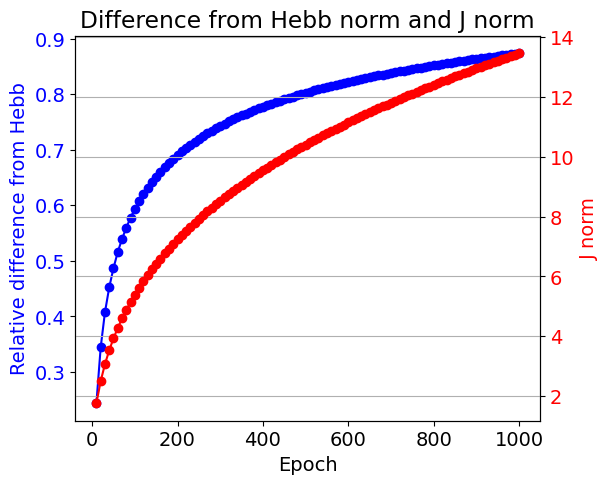

In [ ]:
epochs_arr = np.arange(1,len(hist_J_norm)+1)*valid_every

fig, axs = plt.subplots(1, 1, figsize=(6, 5))

axs.plot(epochs_arr, hist_diff, "o-", color="blue", label="Train")
axs.set_xlabel("Epoch")
axs.set_ylabel("Relative difference from Hebb", color="blue")
axs.tick_params(axis='y', labelcolor="blue")
axs.set_title("Difference from Hebb norm and J norm")

axs2 = axs.twinx()
axs2.plot(epochs_arr, hist_J_norm, "o-", color="red", label="J norm")
axs2.set_ylabel("J norm", color="red")
axs2.tick_params(axis='y', labelcolor="red")

#fig.legend(loc="upper right")
plt.grid(True)
plt.show()

#### Histograms at saved epochs

In [ ]:
loaded_models = []
j_norms = []

for epoch in epochs_to_save:
    epoch = int(epoch) # Ensure epoch is an integer
    model_filename = data_PATH + "models/" + model_name_base + "_epoch_{}.pth".format(epoch)
    checkpoint = torch.load(model_filename, weights_only=False)

    # Instantiate the model and load state dictionary
    model = TwoBodiesModel(N, d, on_sphere).to(device)
    model.load_state_dict(checkpoint['model_state_dict'])

    # Calculate J norm
    j_norm = torch.norm(model.J).item()

    loaded_models.append(model)
    j_norms.append(j_norm)

print("Loaded {} models.".format(len(loaded_models)))
print("J norms: {}".format(j_norms))

Loaded 10 models.
J norms: [1.7638907432556152, 2.235928773880005, 2.911198854446411, 3.7766597270965576, 4.797333240509033, 6.020483016967773, 7.4559760093688965, 9.152588844299316, 11.135608673095703, 13.455083847045898]


In [ ]:
all_stabilities = []

i=0

for model in loaded_models:
    if i%3==0:
    # Assuming dataset is available and contains the training data (xi)
        stabilities = model.compute_stabilities(dataset.xi.to(device), total=True)
        all_stabilities.append(stabilities.cpu().detach().numpy())
    i+=1
print("Computed stabilities for {} models.".format(len(all_stabilities)))

Computed stabilities for 4 models.


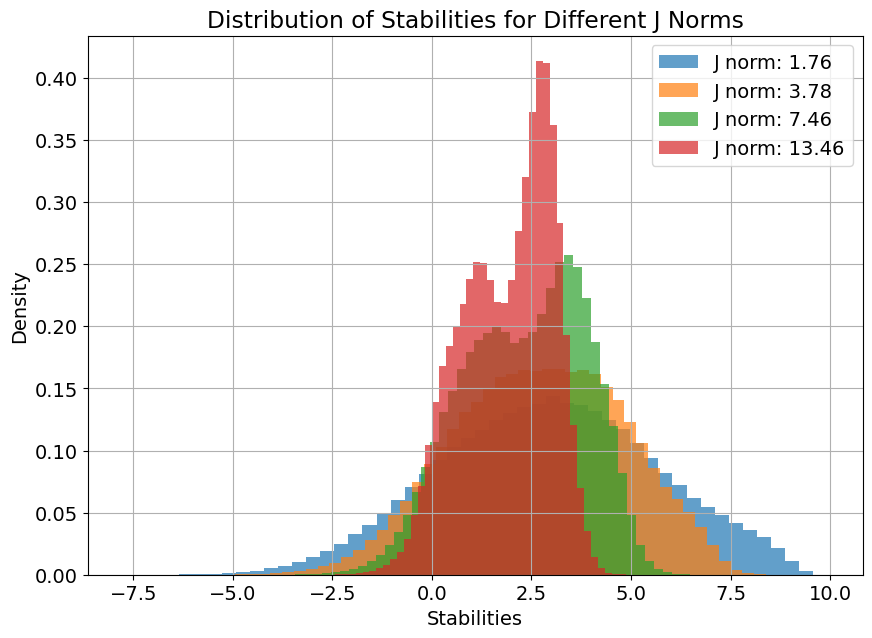

In [ ]:
plt.figure(figsize=(10, 7))

for i, stabilities in enumerate(all_stabilities):
    plt.hist(stabilities.flatten(), bins=50, density=True, alpha=0.7, label=f'J norm: {j_norms[i*3]:.2f}')

plt.xlabel("Stabilities")
plt.ylabel("Density")
plt.title("Distribution of Stabilities for Different J Norms")
plt.legend()
plt.grid(True)
plt.show()

#### Receptive fields at different epochs

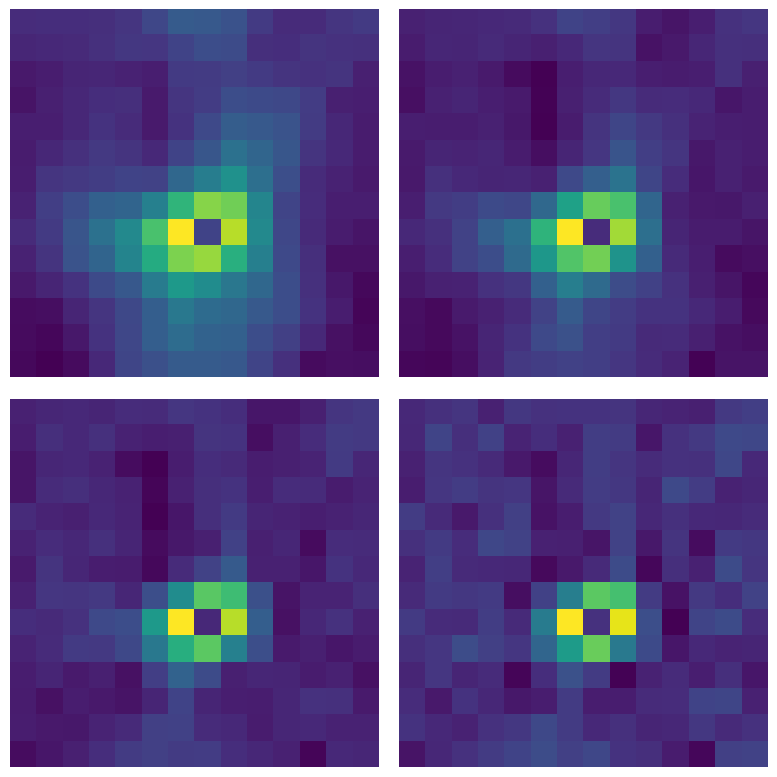

In [ ]:
import matplotlib.pyplot as plt

# Indices of epochs to plot
selected_index = 119
plot_indices = [0, 3, 6, -1]
epochs_to_plot = [int(epochs_to_save[i]) for i in plot_indices]

fig, axes = plt.subplots(2, 2, figsize=(8, 8))
axes = axes.flatten()

J_to_plot_arr = []

for i, epoch_index in enumerate(plot_indices):
    model_to_plot = loaded_models[epoch_index]
     # Replace with the desired index
    J_to_plot = model_to_plot.J[selected_index,:].squeeze().reshape(14,14).cpu().detach().numpy()
    J_to_plot_arr.append(J_to_plot)
    im = axes[i].imshow(J_to_plot, cmap='viridis')
    axes[i].set_title(f'Epoch: {epochs_to_plot[i]}') # Add titles for clarity during development
    axes[i].axis('off') # Turn off axes

# Remove titles and adjust layout for close positioning
for ax in axes:
    ax.set_title('')
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

100%|██████████| 1960/1960 [00:00<00:00, 4320.03it/s]


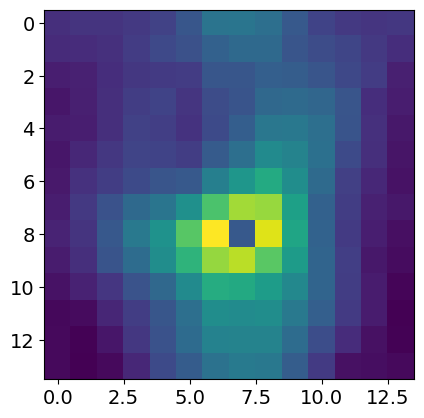

In [ ]:
model2 = copy.deepcopy(model)
model2.Hebb(dataset.xi.to(device), 'Tensorial')

model_to_plot = model2.J[selected_index,:].squeeze().reshape(14,14).cpu().detach().numpy()

plt.imshow(model_to_plot, cmap='viridis')

In [ ]:
to_save = {
    "epochs_arr": epochs_arr,
    "hist_diff": hist_diff,
    "hist_J_norm": hist_J_norm,
    "stabilities": all_stabilities,
    "J_to_plot_arr": J_to_plot_arr,
    "model_to_plot": model_to_plot,
    "j_norms": j_norms,
}

name_save = "MNIST_30_06"
np.save(data_PATH+"graphs/"+name_save, to_save)

### Starting 0.01 Hebb

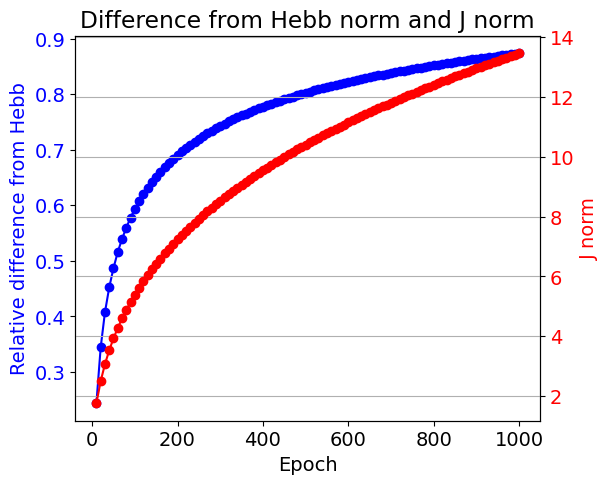

In [ ]:
epochs_arr = np.arange(1,len(hist_J_norm)+1)*valid_every

fig, axs = plt.subplots(1, 1, figsize=(6, 5))

axs.plot(epochs_arr, hist_diff, "o-", color="blue", label="Train")
axs.set_xlabel("Epoch")
axs.set_ylabel("Relative difference from Hebb", color="blue")
axs.tick_params(axis='y', labelcolor="blue")
axs.set_title("Difference from Hebb norm and J norm")

axs2 = axs.twinx()
axs2.plot(epochs_arr, hist_J_norm, "o-", color="red", label="J norm")
axs2.set_ylabel("J norm", color="red")
axs2.tick_params(axis='y', labelcolor="red")

#fig.legend(loc="upper right")
plt.grid(True)
plt.show()

#### Histograms at saved epochs

In [ ]:
loaded_models = []
j_norms = []

for epoch in epochs_to_save:
    epoch = int(epoch) # Ensure epoch is an integer
    model_filename = data_PATH + "models/" + model_name_base + "_epoch_{}.pth".format(epoch)
    checkpoint = torch.load(model_filename, weights_only=False)

    # Instantiate the model and load state dictionary
    model = TwoBodiesModel(N, d, on_sphere).to(device)
    model.load_state_dict(checkpoint['model_state_dict'])

    # Calculate J norm
    j_norm = torch.norm(model.J).item()

    loaded_models.append(model)
    j_norms.append(j_norm)

print("Loaded {} models.".format(len(loaded_models)))
print("J norms: {}".format(j_norms))

Loaded 10 models.
J norms: [1.7638907432556152, 2.235928773880005, 2.911198854446411, 3.7766597270965576, 4.797333240509033, 6.020483016967773, 7.4559760093688965, 9.152588844299316, 11.135608673095703, 13.455083847045898]


In [ ]:
all_stabilities = []

i=0

for model in loaded_models:
    if i%3==0:
    # Assuming dataset is available and contains the training data (xi)
        stabilities = model.compute_stabilities(dataset.xi.to(device), total=True)
        all_stabilities.append(stabilities.cpu().detach().numpy())
    i+=1
print("Computed stabilities for {} models.".format(len(all_stabilities)))

Computed stabilities for 4 models.


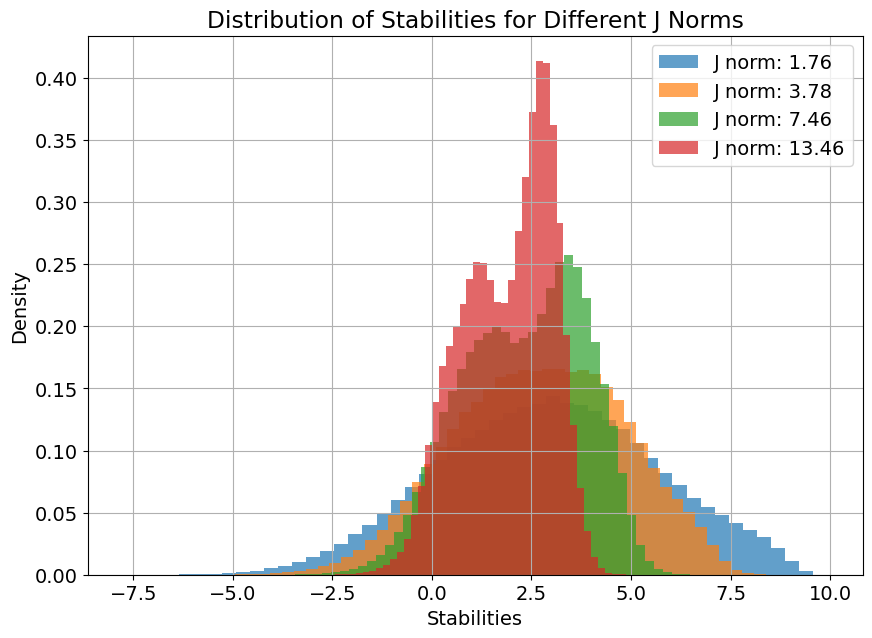

In [ ]:
plt.figure(figsize=(10, 7))

for i, stabilities in enumerate(all_stabilities):
    plt.hist(stabilities.flatten(), bins=50, density=True, alpha=0.7, label=f'J norm: {j_norms[i*3]:.2f}')

plt.xlabel("Stabilities")
plt.ylabel("Density")
plt.title("Distribution of Stabilities for Different J Norms")
plt.legend()
plt.grid(True)
plt.show()

#### Receptive fields at different epochs

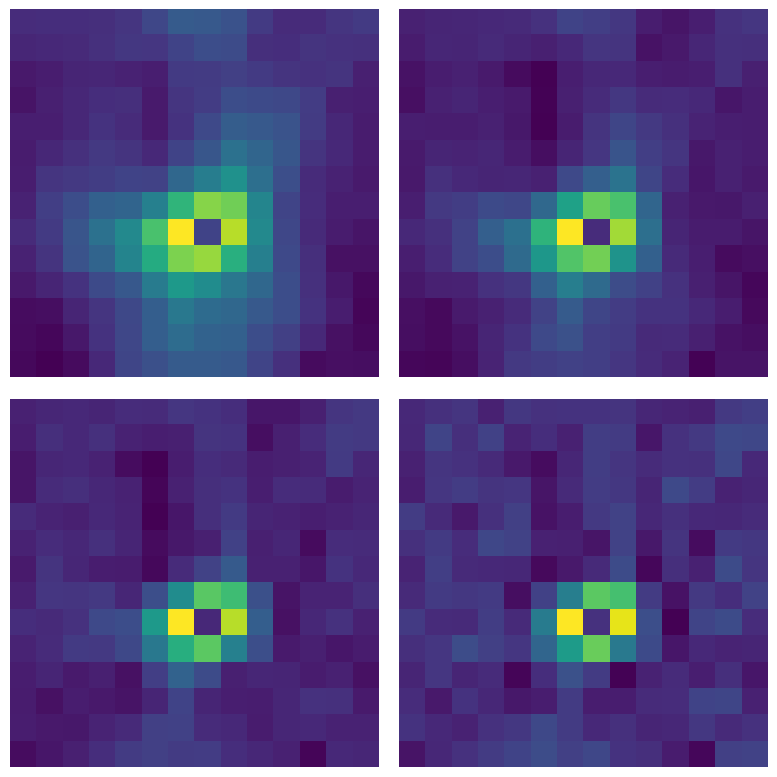

In [ ]:
import matplotlib.pyplot as plt

# Indices of epochs to plot
selected_index = 119
plot_indices = [0, 3, 6, -1]
epochs_to_plot = [int(epochs_to_save[i]) for i in plot_indices]

fig, axes = plt.subplots(2, 2, figsize=(8, 8))
axes = axes.flatten()

for i, epoch_index in enumerate(plot_indices):
    model_to_plot = loaded_models[epoch_index]
     # Replace with the desired index
    J_to_plot = model_to_plot.J[selected_index,:].squeeze().reshape(14,14).cpu().detach().numpy()

    im = axes[i].imshow(J_to_plot, cmap='viridis')
    axes[i].set_title(f'Epoch: {epochs_to_plot[i]}') # Add titles for clarity during development
    axes[i].axis('off') # Turn off axes

# Remove titles and adjust layout for close positioning
for ax in axes:
    ax.set_title('')
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

100%|██████████| 1960/1960 [00:00<00:00, 5337.36it/s]


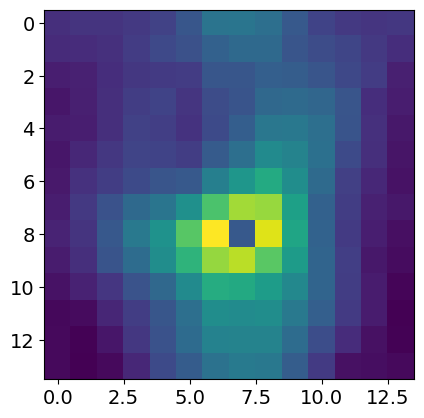

In [ ]:
model2 = copy.deepcopy(model)
model2.Hebb(dataset.xi.to(device), 'Tensorial')

model_to_plot = model2.J[selected_index,:].squeeze().reshape(14,14).cpu().detach().numpy()

plt.imshow(model_to_plot, cmap='viridis')

## Training of single models to analyze results

In [ ]:
N=196
#a_P_values = np.flip(np.logspace(np.log10(0.1), np.log10(100), num=10))
a_P_values = np.flip(np.logspace(np.log10(10), np.log10(100), num=1))

P_test = 10000
D=0
d=1
on_sphere=True

l=2.
valid_every=10
epochs=1001
learning_rate=100.
init_overlap=1.
n=10
max_norm=20

In [ ]:
to_save_overlaps = np.zeros((len(a_P_values),2))

for i_a, a_P in enumerate(a_P_values):
    P = int(a_P*N)
    print("P= ",P)
    batch_size = min(P,1000)
    batch_size_test = batch_size
    np.random.seed(555)

    # Shuffle the images along the first axis (axis=0)
    shuffled_indices = np.random.permutation(images_binarized.shape[0])
    shuffled_images = images_binarized[shuffled_indices]

    # Select the first P images
    selected_images = shuffled_images[:P]
    num_to_test = P_test
    test_images = shuffled_images[P:(P+num_to_test)]

    gc.collect()
    torch.cuda.empty_cache()

    dataset, dataset_test, model = initialize_MNIST(N=N, d=1, on_sphere=True, l=l, device='cuda', selected_images=selected_images, test_images=test_images)
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True, num_workers=2)
    dataloader_test = torch.utils.data.DataLoader(dataset_test, batch_size=batch_size_test, shuffle=False, drop_last=True, num_workers=2)

    model_name = "MNIST_GD_N{}_P{}_init_Hebb_lambda{}_no_batch_no_adamw_binary.pth".format(N,P,D,l)
    model, hist_loss, hist_vloss, hist_asymm, hist_diff, hist_J_norm = train_model(model, dataloader, epochs, learning_rate, device, data_PATH, model_name, init_overlap, n, valid_every=valid_every, alpha=None)

    fake_opt = torch.optim.SGD(model.parameters(), lr=learning_rate)
    save_model = Save_Model(data_PATH+"models/"+model_name)
    save_model(hist_vloss[-1], epochs, model, fake_opt, hist_vloss)

    to_save_overlaps[i_a,0] = hist_vloss[-1]

    counter_test = 0
    vali_loss_test = 0
    for batch_element in dataloader_test:
        counter_test +=1
        inp_data = batch_element
        inp_data = inp_data.to(device)
        input_vectors = start_overlap_binary(inp_data, init_overlap)
        input_vectors = model.normalize_x(input_vectors)
        x_new = model.dyn_n_step(input_vectors, n)
        overlaps = torch.einsum('bnid,bid->bni', x_new, inp_data).mean(dim=-1)         #[b,n
        final_overlaps = overlaps[:,-1]
        max_input_overlap,_ = torch.max(overlaps, dim=-1)
        vloss_test = final_overlaps.mean().cpu().numpy()
        vali_loss_test += vloss_test

    if counter_test !=0:
        vali_loss_test = vali_loss_test/(counter_test)

    to_save_overlaps[i_a,1] = vali_loss_test
    print("Overlap test: ", vali_loss_test)




P=  1960
epoch: 1001, train loss: 0.037198, final_ov: 0.76484, max_ov: 0.94944, lr: 4.00e+00, J_norm: 4.23e+01, asym: 2.128e-02, diff: 1.397e+00
Overlap test:  0.7331868


In [ ]:
name_save = "new_MNIST_GD_N{}_ov{}_curve".format(N,init_overlap)
np.save(data_PATH+"graphs/"+name_save, to_save_overlaps)

In [ ]:
P = 1960
D=0
l=1
d=1
on_sphere=True
learning_rate = 0.001
N = 14*14
model_name = "MNIST_GD_N{}_P{}_init_Hebb_lambda{}_no_batch_no_adamw_binary.pth".format(N,P,D,l)
model = TwoBodiesModel(N, d, on_sphere).to(device)
fake_opt = torch.optim.SGD(model.parameters(), lr=learning_rate)

checkpoint = torch.load(data_PATH+"models/"+model_name, weights_only=False)
epoch = checkpoint['epoch']
hist_vloss  = checkpoint['loss']
model.load_state_dict(checkpoint['model_state_dict'])

<All keys matched successfully>

### P=196

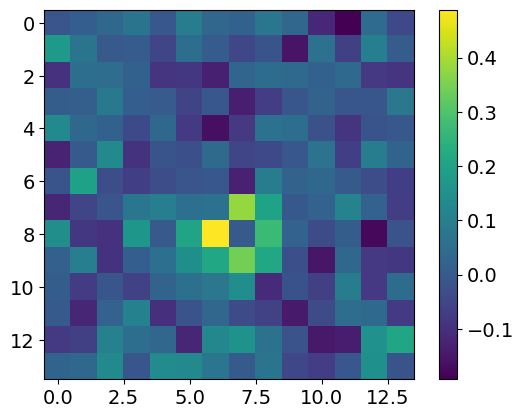

In [ ]:
num = 119
plt.imshow(model.J[:,num].squeeze().reshape(14,14).cpu().detach().numpy())
plt.colorbar()

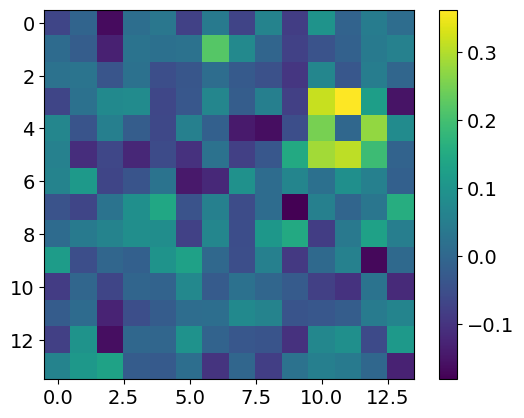

In [ ]:
num = 67
plt.imshow(model.J[:,num].squeeze().reshape(14,14).cpu().detach().numpy())
plt.colorbar()

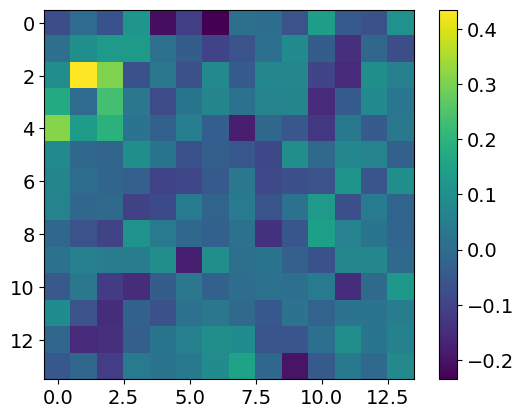

In [ ]:
num = 43
plt.imshow(model.J[:,num].squeeze().reshape(14,14).cpu().detach().numpy())
plt.colorbar()

### P=1960

#### lr=0.1

100%|██████████| 1960/1960 [00:00<00:00, 4213.22it/s]


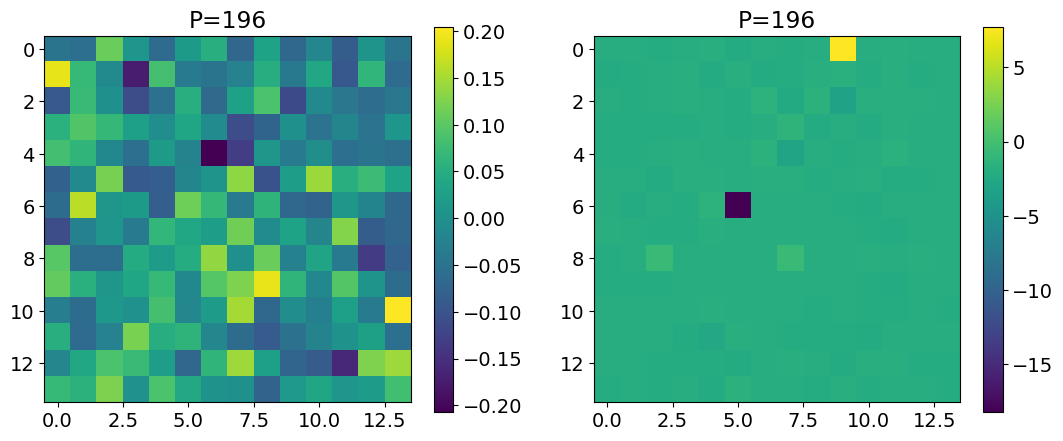

In [ ]:
num = 119

model2 = copy.deepcopy(model)
model3 = copy.deepcopy(model)

model2.Hebb(dataset.xi.to(device), 'Tensorial')

model2.J.data[num,num] = 1.
model3.J.data[num,num] = 1.

fig, axs = plt.subplots(1, 2, figsize=(13, 5))

axs[0].imshow(model.J[:,num].squeeze().reshape(14,14).cpu().detach().numpy())
axs[0].set_title("P=196")

axs[1].imshow(((model3.J[:,num]-model2.J[:,num]*torch.norm(model3.J[:,num]))/(model2.J[:,num])*torch.norm(model3.J[:,num])).squeeze().reshape(14,14).cpu().detach().numpy())
axs[1].set_title("P=196")

plt.colorbar(axs[0].images[0])

plt.colorbar(axs[1].images[0])

#### lr=1.

100%|██████████| 1960/1960 [00:00<00:00, 4321.74it/s]


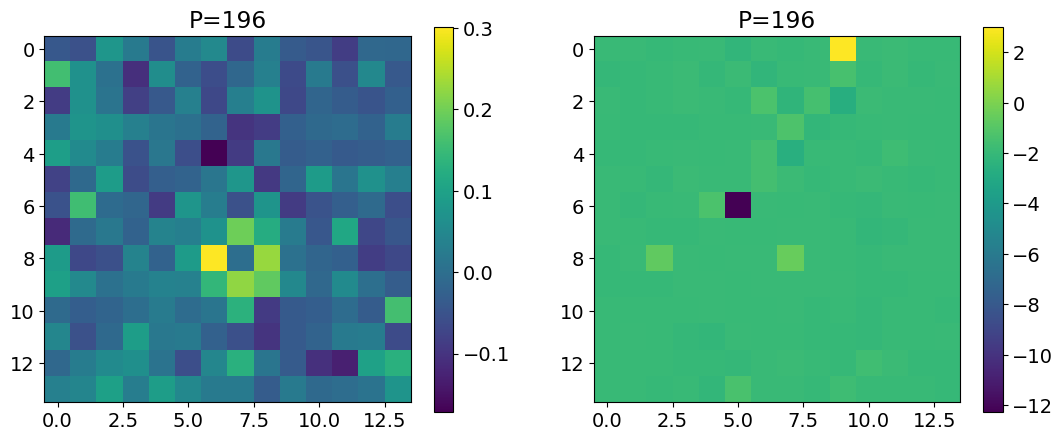

In [ ]:
num = 119

model2 = copy.deepcopy(model)
model3 = copy.deepcopy(model)

model2.Hebb(dataset.xi.to(device), 'Tensorial')

model2.J.data[num,num] = 1.
model3.J.data[num,num] = 1.

fig, axs = plt.subplots(1, 2, figsize=(13, 5))

axs[0].imshow(model.J[:,num].squeeze().reshape(14,14).cpu().detach().numpy())
axs[0].set_title("P=196")

axs[1].imshow(((model3.J[:,num]-model2.J[:,num]*torch.norm(model3.J[:,num]))/(model2.J[:,num])*torch.norm(model3.J[:,num])).squeeze().reshape(14,14).cpu().detach().numpy())
axs[1].set_title("P=196")

plt.colorbar(axs[0].images[0])

plt.colorbar(axs[1].images[0])

#### lr=10

100%|██████████| 1960/1960 [00:00<00:00, 2864.78it/s]


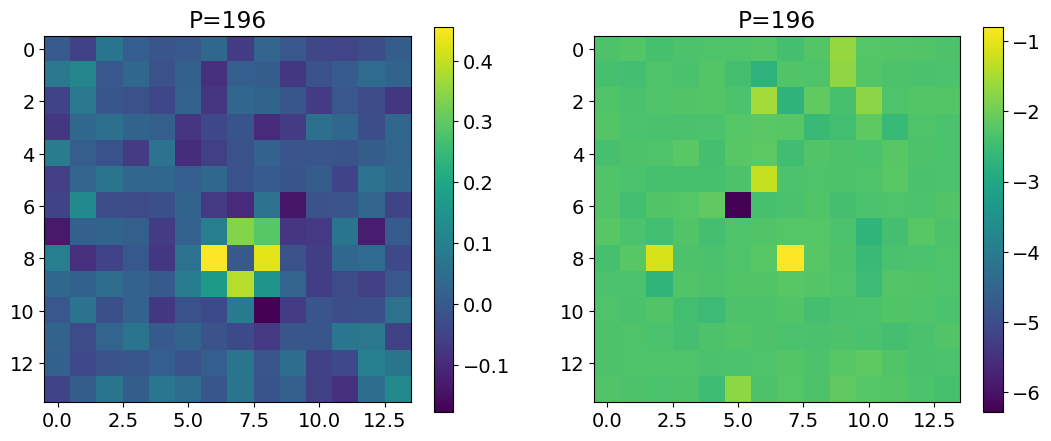

In [ ]:
num = 119

model2 = copy.deepcopy(model)
model3 = copy.deepcopy(model)

model2.Hebb(dataset.xi.to(device), 'Tensorial')

model2.J.data[num,num] = 1.
model3.J.data[num,num] = 1.

fig, axs = plt.subplots(1, 2, figsize=(13, 5))

axs[0].imshow(model.J[:,num].squeeze().reshape(14,14).cpu().detach().numpy())
axs[0].set_title("P=196")

axs[1].imshow(((model3.J[:,num]-model2.J[:,num]*torch.norm(model3.J[:,num]))/(model2.J[:,num])*torch.norm(model3.J[:,num])).squeeze().reshape(14,14).cpu().detach().numpy())
axs[1].set_title("P=196")

plt.colorbar(axs[0].images[0])

plt.colorbar(axs[1].images[0])

#### lr=100

100%|██████████| 1960/1960 [00:00<00:00, 3416.89it/s]


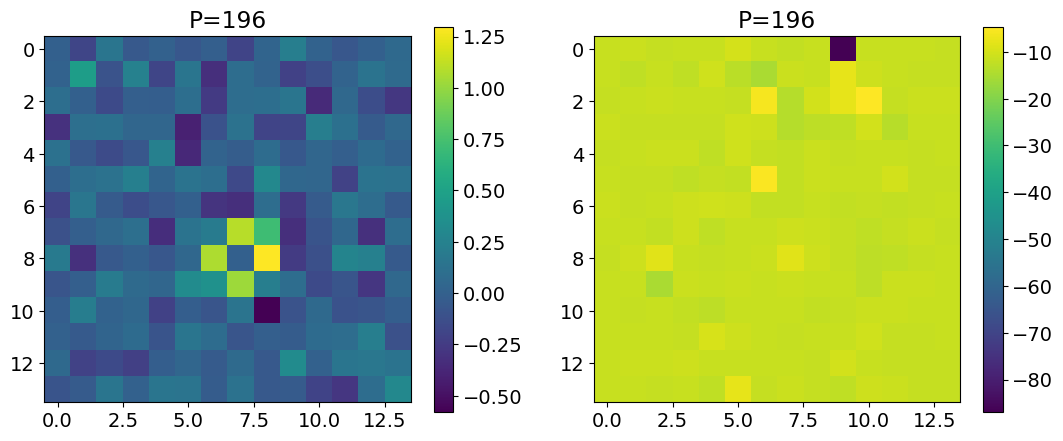

In [ ]:
num = 119

model2 = copy.deepcopy(model)
model3 = copy.deepcopy(model)

model2.Hebb(dataset.xi.to(device), 'Tensorial')

model2.J.data[num,num] = 1.
model3.J.data[num,num] = 1.

fig, axs = plt.subplots(1, 2, figsize=(13, 5))

axs[0].imshow(model.J[:,num].squeeze().reshape(14,14).cpu().detach().numpy())
axs[0].set_title("P=196")

axs[1].imshow(((model3.J[:,num]-model2.J[:,num]*torch.norm(model3.J[:,num]))/(model2.J[:,num])*torch.norm(model3.J[:,num])).squeeze().reshape(14,14).cpu().detach().numpy())
axs[1].set_title("P=196")

plt.colorbar(axs[0].images[0])

plt.colorbar(axs[1].images[0])

#### lr=10

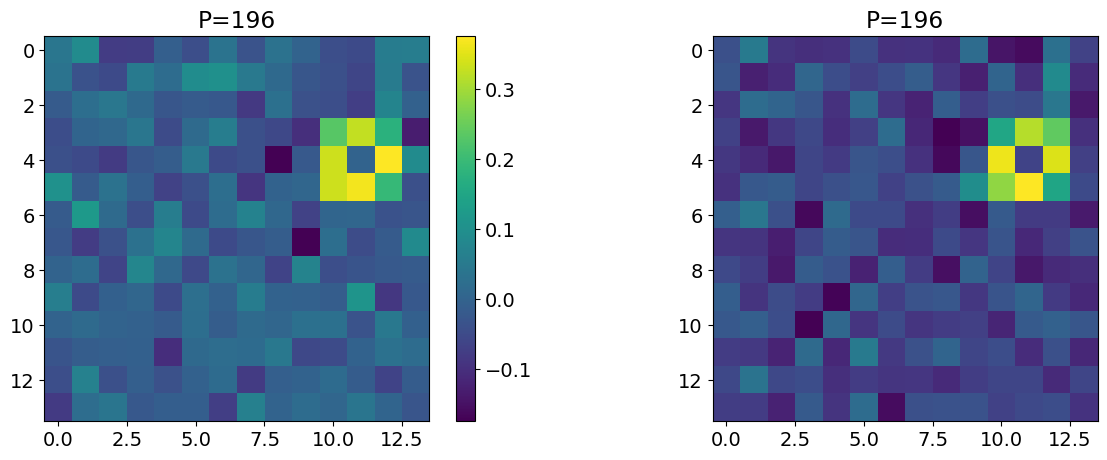

In [ ]:
num = 67

fig, axs = plt.subplots(1, 2, figsize=(15, 5))

axs[0].imshow(model.J[:,num].squeeze().reshape(14,14).cpu().detach().numpy())
axs[0].set_title("P=196")

axs[1].imshow(model.J[num,:].squeeze().reshape(14,14).cpu().detach().numpy())
axs[1].set_title("P=196")

plt.colorbar(axs[0].images[0])



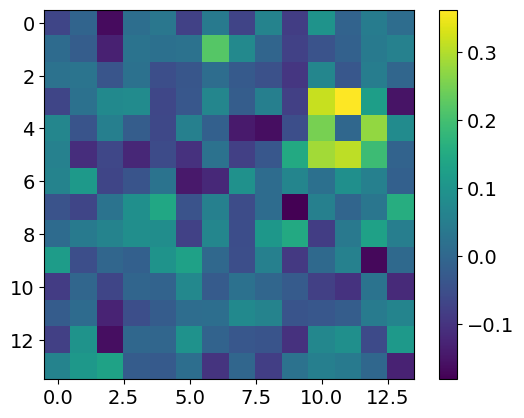

In [ ]:
num = 67
plt.imshow(model.J[:,num].squeeze().reshape(14,14).cpu().detach().numpy())
plt.colorbar()

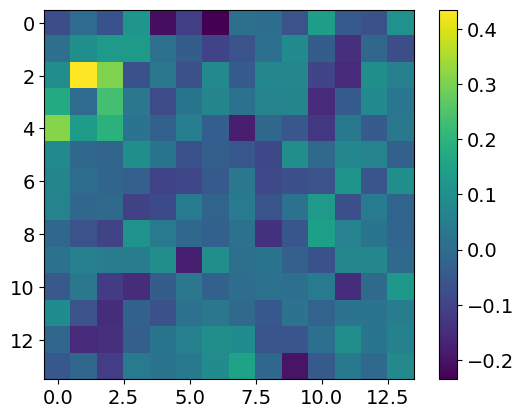

In [ ]:
num = 43
plt.imshow(model.J[:,num].squeeze().reshape(14,14).cpu().detach().numpy())
plt.colorbar()

### P=9097

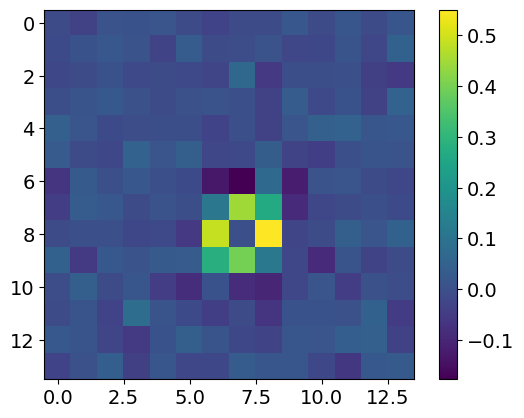

In [ ]:
num = 119
plt.imshow(model.J[:,num].squeeze().reshape(14,14).cpu().detach().numpy())
plt.colorbar()

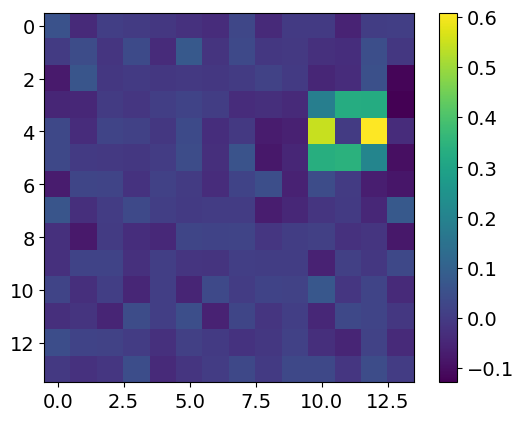

In [ ]:
num = 67
plt.imshow(model.J[:,num].squeeze().reshape(14,14).cpu().detach().numpy())
plt.colorbar()

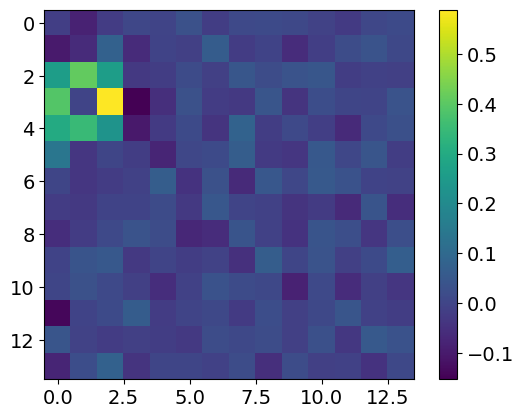

In [ ]:
num = 43
plt.imshow(model.J[:,num].squeeze().reshape(14,14).cpu().detach().numpy())
plt.colorbar()

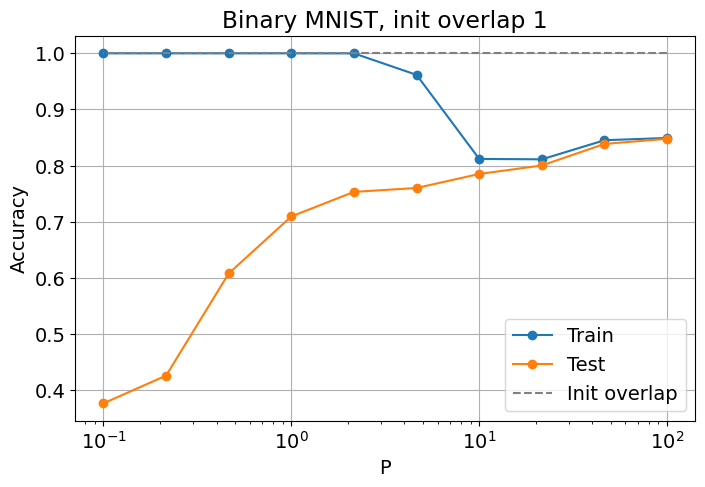

In [ ]:
plt.figure(figsize=(8,5))
plt.title("Binary MNIST, init overlap 1")
plt.plot(a_P_values,to_save_overlaps[:,0], "o-", label="Train")
plt.plot(a_P_values,to_save_overlaps[:,1], "o-", label="Test")
plt.plot(a_P_values, np.repeat(init_overlap, len(a_P_values)), "--", color="grey", label="Init overlap")
plt.legend()
plt.xlabel("P")
plt.ylabel("Accuracy")
plt.grid()
plt.xscale("log")

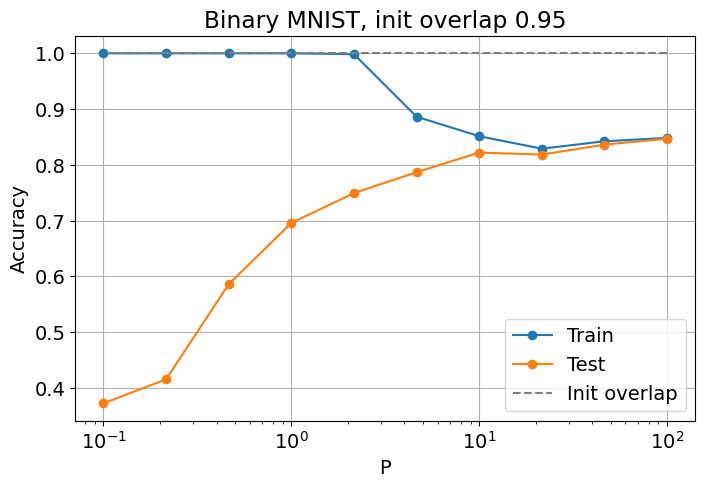

In [ ]:
plt.figure(figsize=(8,5))
plt.title("Binary MNIST, init overlap 0.95")
plt.plot(a_P_values,to_save_overlaps[:,0], "o-", label="Train")
plt.plot(a_P_values,to_save_overlaps[:,1], "o-", label="Test")
plt.plot(a_P_values, np.repeat(init_overlap, len(a_P_values)), "--", color="grey", label="Init overlap")
plt.legend()
plt.xlabel("P")
plt.ylabel("Accuracy")
plt.grid()
plt.xscale("log")
#plt.savefig(data_PATH+"figures/"+name_save+".png")

## Training varying $\alpha$ and memorization-to-generalization transition

In [ ]:
N=196
a_P_values = np.flip(np.logspace(np.log10(0.1), np.log10(100), num=10))

P_test = 10000
D=0
d=1
on_sphere=True

l=0.1
valid_every=10
epochs=301
learning_rate=100
init_overlap=1.
n=10
max_norm=20

In [ ]:
init_overlap=1.

to_save_overlaps = np.zeros((len(a_P_values),3))

for i_a, a_P in enumerate(a_P_values):
    P = int(a_P*N)
    print("P= ",P)
    batch_size = min(P,1000)
    batch_size_test = batch_size
    np.random.seed(555)

    # Shuffle the images along the first axis (axis=0)
    shuffled_indices = np.random.permutation(images_binarized.shape[0])
    shuffled_images = images_binarized[shuffled_indices]

    # Select the first P images
    selected_images = shuffled_images[:P]
    num_to_test = P_test
    test_images = shuffled_images[P:(P+num_to_test)]

    gc.collect()
    torch.cuda.empty_cache()

    dataset, dataset_test, model = initialize_MNIST(N=N, d=1, on_sphere=True, l=l, device='cuda', selected_images=selected_images, test_images=test_images)
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True, num_workers=2)
    dataloader_test = torch.utils.data.DataLoader(dataset_test, batch_size=batch_size_test, shuffle=False, drop_last=True, num_workers=2)

    model_name = "MNIST_GD_N{}_P{}_init_Hebb_lambda{}_no_batch_no_adamw_binary.pth".format(N,P,D,l)

    model = TwoBodiesModel(N, d, on_sphere).to(device)
    fake_opt = torch.optim.SGD(model.parameters(), lr=learning_rate)

    checkpoint = torch.load(data_PATH+"models/"+model_name, weights_only=False)
    epoch = checkpoint['epoch']
    hist_vloss  = checkpoint['loss']
    model.load_state_dict(checkpoint['model_state_dict'])

    counter = 0
    vali_loss = 0
    for batch_element in dataloader:
        counter +=1
        inp_data = batch_element
        inp_data = inp_data.to(device)
        input_vectors = start_overlap_binary(inp_data, init_overlap)
        input_vectors = model.normalize_x(input_vectors)
        x_new = model.dyn_n_step(input_vectors, n)
        overlaps = torch.einsum('bnid,bid->bni', x_new, inp_data).mean(dim=-1)         #[b,n
        final_overlaps = overlaps[:,-1]
        max_input_overlap,_ = torch.max(overlaps, dim=-1)
        vloss = final_overlaps.mean().cpu().numpy()
        vali_loss += vloss

    if counter !=0:
        vali_loss = vali_loss/(counter)

    to_save_overlaps[i_a,0] = vali_loss

    counter_test = 0
    vali_loss_test = 0
    for batch_element in dataloader_test:
        counter_test +=1
        inp_data = batch_element
        inp_data = inp_data.to(device)
        input_vectors = start_overlap_binary(inp_data, init_overlap)
        input_vectors = model.normalize_x(input_vectors)
        x_new = model.dyn_n_step(input_vectors, n)
        overlaps = torch.einsum('bnid,bid->bni', x_new, inp_data).mean(dim=-1)         #[b,n
        final_overlaps = overlaps[:,-1]
        max_input_overlap,_ = torch.max(overlaps, dim=-1)
        vloss_test = final_overlaps.mean().cpu().numpy()
        vali_loss_test += vloss_test

    if counter_test !=0:
        vali_loss_test = vali_loss_test/(counter_test)

    to_save_overlaps[i_a,1] = vali_loss_test

    #### RANDOM

    counter_test = 0
    vali_loss_test = 0
    for batch_element in dataloader_test:
        counter_test +=1
        inp_data = batch_element
        inp_data = inp_data.to(device)

        inp_data = (torch.randint(0, 2, (batch_size_test, N, 1)).float() * 2 - 1).to(device)
        input_vectors = start_overlap_binary(inp_data, init_overlap).to(device)

        x_new = model.dyn_n_step(input_vectors, n)
        overlaps = torch.einsum('bnid,bid->bni', x_new, inp_data).mean(dim=-1)         #[b,n
        final_overlaps = overlaps[:,-1]
        max_input_overlap,_ = torch.max(overlaps, dim=-1)
        vloss_test = final_overlaps.mean().cpu().numpy()
        vali_loss_test += vloss_test

    if counter_test !=0:
        vali_loss_test = vali_loss_test/(counter_test)

    to_save_overlaps[i_a,2] = vali_loss_test
    print("Overlap test: ", vali_loss_test)


P=  19600
Overlap test:  0.37139085
P=  9097
Overlap test:  0.36952758
P=  4222
Overlap test:  0.34773675
P=  1960
Overlap test:  0.2560143
P=  909
Overlap test:  0.22651348
P=  422
Overlap test:  0.19302179
P=  196
Overlap test:  0.16222204
P=  90
Overlap test:  0.14465386
P=  42
Overlap test:  0.114433564
P=  19
Overlap test:  0.09271174


In [ ]:
name_save = "new_MNIST_GD_N{}_ov{}_curve_from_random".format(N,init_overlap)
np.save(data_PATH+"graphs/"+name_save, to_save_overlaps)

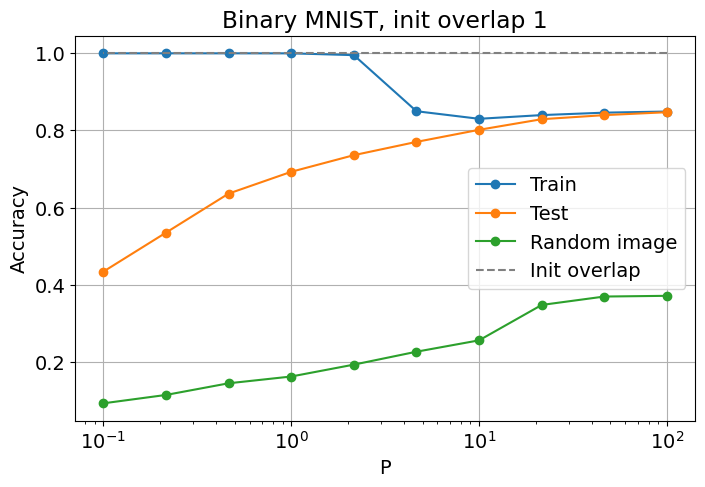

In [ ]:
plt.figure(figsize=(8,5))
plt.title("Binary MNIST, init overlap 1")
plt.plot(a_P_values,to_save_overlaps[:,0], "o-", label="Train")
plt.plot(a_P_values,to_save_overlaps[:,1], "o-", label="Test")
plt.plot(a_P_values,to_save_overlaps[:,2], "o-", label="Random image")
plt.plot(a_P_values, np.repeat(init_overlap, len(a_P_values)), "--", color="grey", label="Init overlap")
plt.legend()
plt.xlabel("P")
plt.ylabel("Accuracy")
plt.grid()
plt.xscale("log")

# Test on images

In [ ]:
N=196
alpha_arr = np.flip(np.logspace(np.log10(0.1), np.log10(100), num=10))
d=1
on_sphere = True
D=0
learning_rate = 100
l=0.1
P_test = 10000

model_arr = np.empty((len(alpha_arr)), dtype=object)
hist_vloss_arr = np.empty((len(alpha_arr)), dtype=object)

for i_a, alpha in enumerate(alpha_arr):
    P = int(alpha*N)
    model_arr[i_a] = TwoBodiesModel(N, d, on_sphere).to(device)
    fake_opt = torch.optim.SGD(model_arr[i_a].parameters(), lr=learning_rate)
    model_name = "MNIST_GD_N{}_P{}_init_Hebb_lambda{}_no_batch_no_adamw_binary.pth".format(N,P,D,l)
    checkpoint = torch.load(data_PATH+"models/"+model_name, weights_only=False)
    epoch = checkpoint['epoch']
    hist_vloss_arr[i_a]  = checkpoint['loss']
    model_arr[i_a].load_state_dict(checkpoint['model_state_dict'])
    fake_opt.load_state_dict(checkpoint["optimizer_state_dict"])


In [ ]:
i_a = 0
P = int(alpha_arr[i_a]*N)

np.random.seed(555)

# Shuffle the images along the first axis (axis=0)
shuffled_indices = np.random.permutation(images_binarized.shape[0])
shuffled_images = images_binarized[shuffled_indices]
# Select the first P images
selected_images = shuffled_images[:P]
num_to_test = P_test
test_images = shuffled_images[P:(P+num_to_test)]
gc.collect()
torch.cuda.empty_cache()

dataset, dataset_test, model = initialize_MNIST(N=N, d=1, on_sphere=True, l=l, device='cuda', selected_images=selected_images, test_images=test_images)

model = model_arr[i_a]

print(alpha_arr[i_a])

100.0


## Images

In [ ]:
dataset_random = CustomDataset(P, N, D, d, seed=555, sigma=0.5, on_sphere=on_sphere, coefficients="binary")
dataset_random.xi = torch.randint(0,2,(P,N,1)).float()*2-1

torch.Size([3, 196, 1])


<ipython-input-35-e7face9271d6>:40: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  modified_images_train = torch.tensor(modified_images_train).cpu()
<ipython-input-35-e7face9271d6>:41: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  modified_images_test = torch.tensor(modified_images_test).cpu()


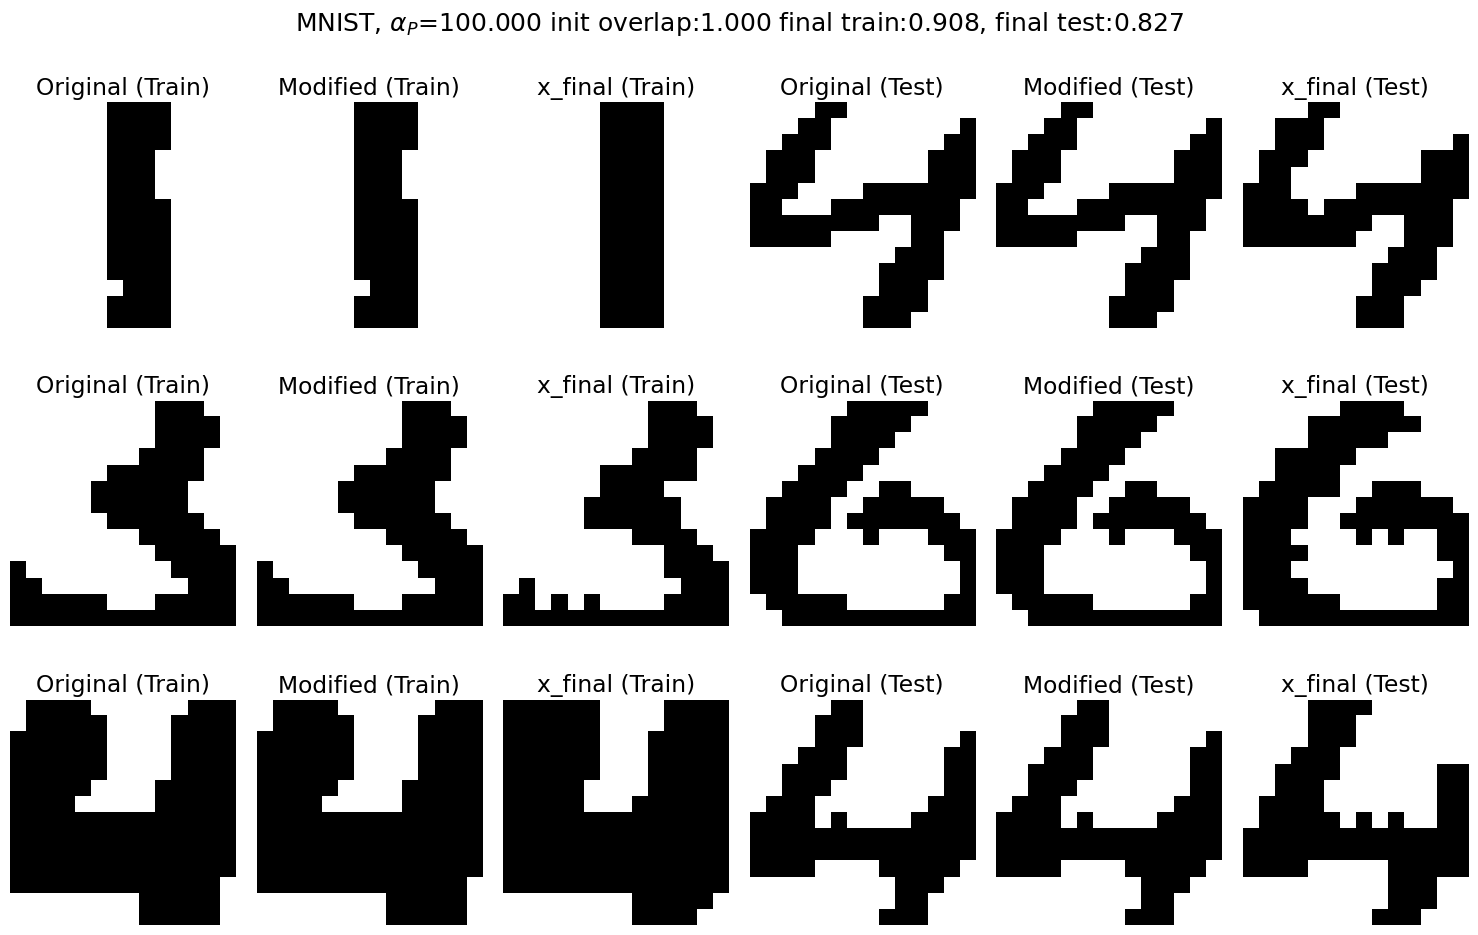

In [ ]:
indices = [0,1,2]
init_overlap = 1.0
n=100

title = r"MNIST, $\alpha_P$={:.3f}".format(float(P)/N)

to_save, to_save_test = plot_model_computations(
    model=model,
    dataset=dataset,
    dataset_test=dataset_test,
    indices=indices,
    init_overlap=init_overlap,
    n=n,
    device=device,
    suptitle=title
)

torch.Size([3, 196, 1])


<ipython-input-35-e7face9271d6>:40: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  modified_images_train = torch.tensor(modified_images_train).cpu()
<ipython-input-35-e7face9271d6>:41: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  modified_images_test = torch.tensor(modified_images_test).cpu()


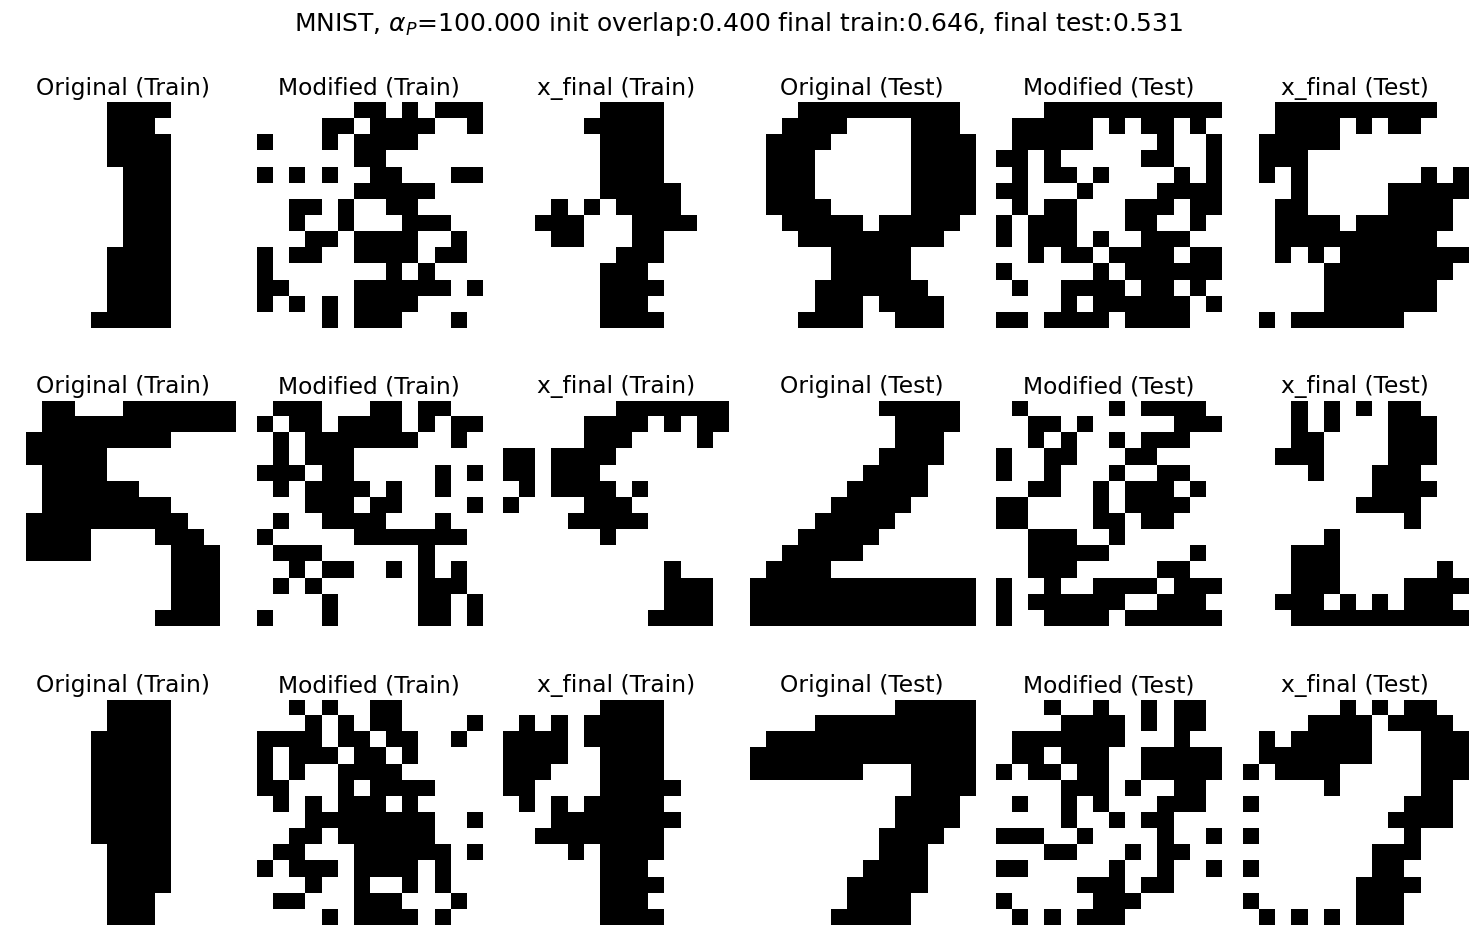

In [ ]:
indices = [3,4,5]
init_overlap = 0.4
n=100

title = r"MNIST, $\alpha_P$={:.3f}".format(float(P)/N)

to_save, to_save_test = plot_model_computations(
    model=model,
    dataset=dataset,
    dataset_test=dataset_test,
    indices=indices,
    init_overlap=init_overlap,
    n=n,
    device=device,
    suptitle=title
)

In [ ]:
name_save = "MNIST_GD_N{}_ov{}_images_train".format(N,init_overlap)
np.save(data_PATH+"graphs/"+name_save, to_save)

name_save = "MNIST_GD_N{}_ov{}_images_test".format(N,init_overlap)
np.save(data_PATH+"graphs/"+name_save, to_save_test)

<ipython-input-72-47fa016611a5>:26: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  modified_images_train = torch.tensor(modified_images_train).cpu()
<ipython-input-72-47fa016611a5>:27: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  modified_images_test = torch.tensor(modified_images_test).cpu()


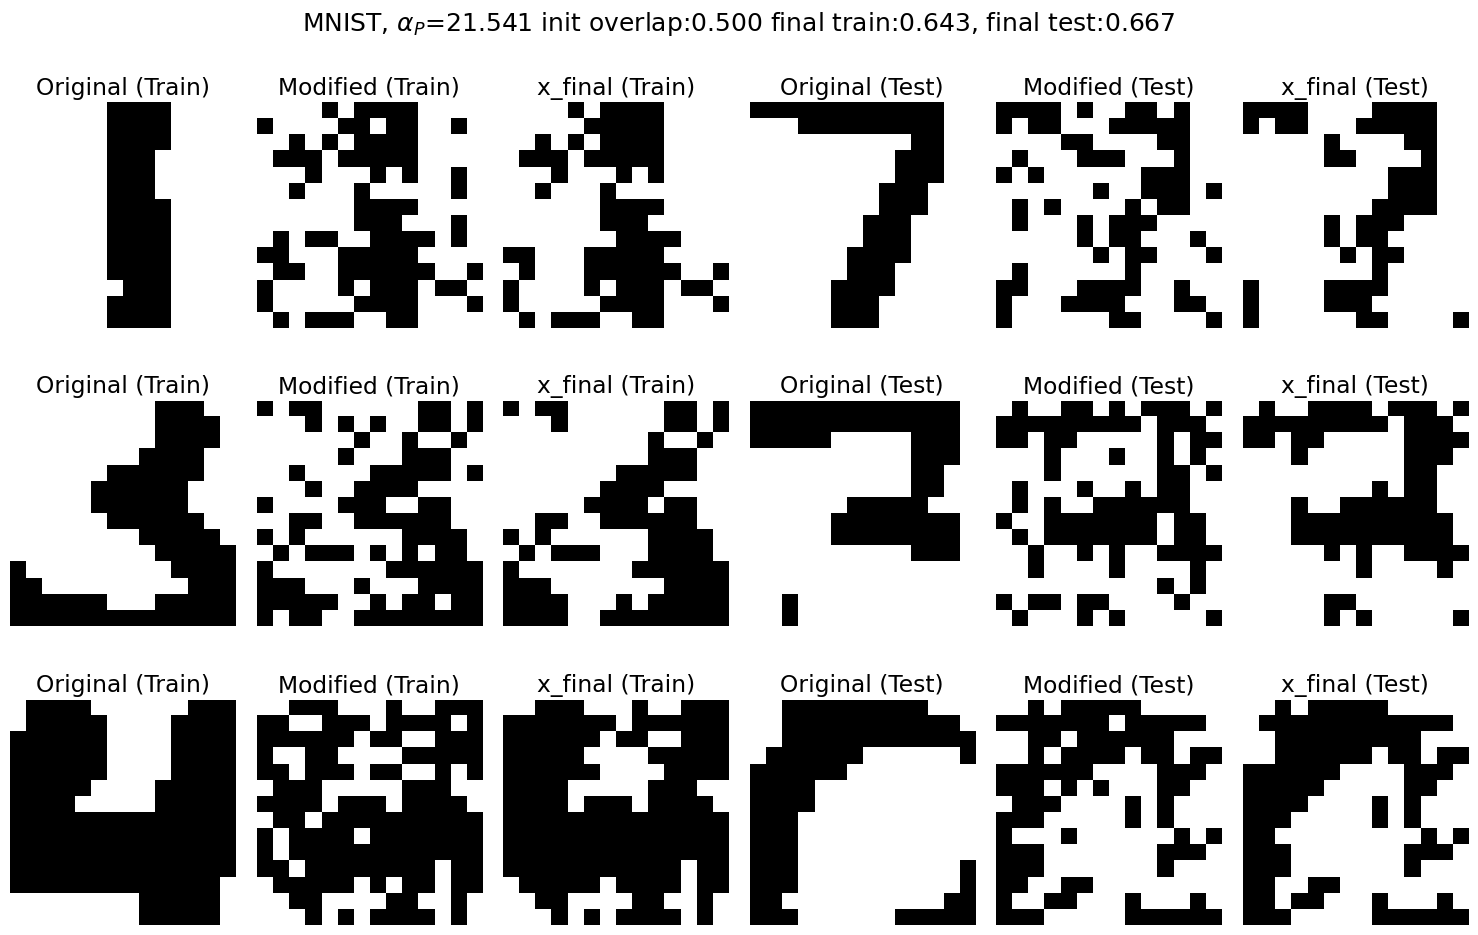

In [ ]:
indices = [0,1,2]
init_overlap = 0.5
n=100

title = r"MNIST, $\alpha_P$={:.3f}".format(float(P)/N)

plot_model_computations(
    model=model,
    dataset=dataset,
    dataset_test=dataset_test,
    indices=indices,
    init_overlap=init_overlap,
    n=n,
    device=device,
    suptitle=title
)

In [ ]:
batch_size_test = min(P,1000)
init_overlap = 0.9
dataloader_test = torch.utils.data.DataLoader(dataset_test, batch_size=batch_size_test, shuffle=False, drop_last=True, num_workers=2)

counter_test = 0
vali_loss_test = 0
for batch_element in dataloader_test:
    counter_test +=1
    inp_data = batch_element
    inp_data = inp_data.to(device)
    input_vectors = start_overlap_binary(inp_data, init_overlap)
    input_vectors = model.normalize_x(input_vectors)
    x_new = model.dyn_n_step(input_vectors, n)
    overlaps = torch.einsum('bnid,bid->bni', x_new, inp_data).mean(dim=-1)         #[b,n
    final_overlaps = overlaps[:,-1]
    max_input_overlap,_ = torch.max(overlaps, dim=-1)
    vloss_test = final_overlaps.mean().cpu().numpy()
    vali_loss_test += vloss_test

if counter_test !=0:
    vali_loss_test = vali_loss_test/(counter_test)

print("Overlap test: ", vali_loss_test)

Overlap test:  0.9517785966396332
